# Per-State Analysis: KP Model External Validation on All of Us Data

**Current Model:** Gestational Hypertension at 12 weeks (GHTN_12w)  
The goal is to evaluate how KP-trained model performance varies across US states  
**Looks into:**
1. Does performance degrade with geographic distance from California (training site)?
2. Is performance degradation due to geography or demographic differences?
3. Which states have AoUs sample populations most similar/dissimilar to California?

**Method:**
- Uses **state_of_residence_concept_id** from person table
- Applies same approach as EV notebook (padding Nans)
- 20% fine-tuning on AoU data, 80% evaluation
- Bootstrap confidence intervals (500 iterations)
- Analyzes both geographic distance and demographic similarity to California


File is commented out because it relies on external models built on the KPNC dataset.

## Setup 

In [1]:
# import pandas as pd
# import numpy as np
# import os
# from math import radians, cos, sin, asin, sqrt
# import warnings
# warnings.filterwarnings('ignore')

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.impute import SimpleImputer
# from sklearn.metrics import (
#     roc_auc_score, auc, precision_recall_curve,
#     accuracy_score, confusion_matrix, 
#     average_precision_score, balanced_accuracy_score, 
#     precision_score, recall_score
# )
# from sklearn import utils

# from xgboost import XGBClassifier
# import xgboost as xgb

# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy import stats
# from collections import defaultdict



In [2]:
# # Environment setup
# data_subfolder = 'pregnancy_cohort_1'
# version = %env WORKSPACE_CDR
# my_bucket = os.getenv('WORKSPACE_BUCKET')

# print(f"Workspace CDR: {version}")
# print(f"Workspace bucket: {my_bucket}")

Workspace CDR: fc-aou-cdr-prod-ct.C2022Q4R13
Workspace bucket: gs://fc-secure-55bd8d31-2bae-47d6-a9d4-72c90305316e


## Data Loading

Load All of Us cohort data components

In [3]:
# print("Loading All of Us cohort data...\n")

# # Load data components
# df_outcomes = pd.read_pickle('pregnancy_cohort_outcomes_date.pkl')
# df_hx = pd.read_pickle('pregnancy_cohort_hx_date.pkl')
# df_demo = pd.read_csv('pregnancy_demographics_date.csv')
# df_labs = pd.read_csv('labs_hold_12w_date.csv')
# df_vitals = pd.read_csv('vitals_hold_12w_date.csv')

# print(f"Outcomes shape: {df_outcomes.shape}")
# print(f"Medical history shape: {df_hx.shape}")
# print(f"Demographics shape: {df_demo.shape}")
# print(f"Labs shape: {df_labs.shape}")
# print(f"Vitals shape: {df_vitals.shape}")

Loading All of Us cohort data...

Outcomes shape: (6940, 21)
Medical history shape: (6940, 34)
Demographics shape: (6940, 15)
Labs shape: (4707, 121)
Vitals shape: (5318, 43)


## Data Merging

In [4]:
# print("Merging datasets...\n")

# # Merge outcomes with medical history
# df = df_outcomes.merge(df_hx, how='left', on='id')

# # Merge with demographics
# df = df.merge(df_demo, how='left', on='id')

# # Merge labs and vitals first
# labs_vitals = df_vitals.merge(df_labs, how='outer', on='id')

# # Then merge with main dataframe (inner join to keep only episodes with vital/lab data)
# df = df.merge(labs_vitals, how='inner', on='id')

# print(f"Merged dataset shape: {df.shape}")
# print(f"Total pregnancies: {len(df):,}")

Merging datasets...

Merged dataset shape: (5594, 230)
Total pregnancies: 5,594


## Features

In [5]:
# print("Engineering features...\n")

# # Convert censor_date to timezone-naive datetime
# for i in range(len(df)):
#     df.loc[i, 'censor_date_x'] = pd.to_datetime(df.loc[i, 'censor_date_x']).replace(tzinfo=None)

# # Calculate maternal age at conception
# df['mage'] = (np.floor(
#     (pd.to_datetime(df['censor_date_x']) - pd.to_datetime(df['birth_date'])).dt.days / 365
# )).astype(int)


# # Rename outcome columns for consistency
# df.rename(columns={
#     'Gestational Diabetes': 'GDM_1', 
#     'Pre-eclampsia': 'PE', 
#     'Gestational_Hypertension': 'GHTN',
#     'Eclampsia': 'E'
# }, inplace=True)


# # Calculate parity
# df['parity'] = (df.groupby('person_id_x')['censor_date_x'].transform('nunique') > 1).astype(int)


# # Clean BMI outliers
# df['PPREG_BMI'] = df['PPREG_BMI'].mask(
#     (df['PPREG_BMI'] < 10) | (df['PPREG_BMI'] > 100), 
#     np.nan
# )



Engineering features...



### Race/Ethnicity Categories

In [6]:
# # Create race/ethnicity categories
# df['Hispanic'] = df['ethnicity'] == 'Hispanic or Latino'
# df['NH_White'] = (df['ethnicity'] != 'Hispanic or Latino') & (df['race'] == 'White')
# df['NH_Black'] = (df['ethnicity'] != 'Hispanic or Latino') & (df['race'] == 'Black or African American')
# df['NH_Asian'] = (df['ethnicity'] != 'Hispanic or Latino') & (
#     df['race'].isin(['Asian', 'Native Hawaiian or Other Pacific Islander'])
# )
# df['Other'] = (df['ethnicity'] != 'Hispanic or Latino') & (
#     ~df['race'].isin(['White', 'Black or African American', 'Asian', 'Native Hawaiian or Other Pacific Islander'])
# )

# # Convert to integer
# df[['Hispanic', 'NH_White', 'NH_Black', 'NH_Asian', 'Other']] = \
#     df[['Hispanic', 'NH_White', 'NH_Black', 'NH_Asian', 'Other']].astype(int)


# # Distribution
# print("\nRace/Ethnicity Distribution:")
# for race in ['Hispanic', 'NH_White', 'NH_Black', 'NH_Asian', 'Other']:
#     n = df[race].sum()
#     pct = n / len(df) * 100
#     print(f"  {race}: {n:,} ({pct:.1f}%)")


Race/Ethnicity Distribution:
  Hispanic: 2,400 (42.9%)
  NH_White: 1,821 (32.6%)
  NH_Black: 905 (16.2%)
  NH_Asian: 189 (3.4%)
  Other: 279 (5.0%)


###  Remove Pregnancies Without Vital/Lab Data

In [7]:
# # Remove rows with no vital/lab data at all
# before_count = len(df)
# df = df.dropna(subset=df.filter(regex=r"^(ep|pp)").columns, how="all")
# after_count = len(df)

# print(f"Removed {before_count - after_count:,} pregnancies with no vital/lab data")
# print(f"Final dataset shape: {df.shape}")

Removed 0 pregnancies with no vital/lab data
Final dataset shape: (5594, 237)


## Add State Information

 Use `state_of_residence_concept_id` from person table 

In [8]:
# print("Querying state information from All of Us...\n")

# # Query to get state of residence using correct field
# state_query = f"""
# SELECT 
#     person_id,
#     COALESCE(state_of_residence_concept_id, 0) as state_concept_id,
#     state.concept_name as state_name
# FROM `{version}.person` person
# LEFT JOIN `{version}.concept` state
#     ON person.state_of_residence_concept_id = state.concept_id
# WHERE person_id IN ({','.join(map(str, df['person_id_x'].unique()))})
# """

# df_states = pd.read_gbq(state_query, dialect='standard')

# print(f"State query returned {len(df_states):,} records")
# print(f"Unique states found: {df_states['state_name'].nunique()}")

# df_states = df_states.rename(columns={'person_id': 'person_id_for_merge'})

# # Merge with main dataframe
# df = df.merge(df_states, 
#               left_on='person_id_x', 
#               right_on='person_id_for_merge', 
#               how='left')
# df = df.drop(columns=['person_id_for_merge'])

# # Clean state names (remove "PII State: " prefix if present)
# df['state_clean'] = df['state_name'].str.replace('PII State: ', '', regex=False)

# print(f"\n State information merged")
# print(f"Total states represented: {df['state_clean'].nunique()}")
# print(f"Pregnancies with missing state: {df['state_clean'].isna().sum():,}")

# print("\nTop 10 states by sample size:")
# print(df['state_clean'].value_counts().head(10))



Querying state information from All of Us...

State query returned 4,920 records
Unique states found: 28

 State information merged
Total states represented: 28
Pregnancies with missing state: 0

Top 10 states by sample size:
state_clean
NY    1566
CA     737
AZ     652
MA     627
PA     614
AL     458
IL     345
WI     273
MI     173
FL      50
Name: count, dtype: int64


## Define Feature List

Features from KP-trained model (exact order matters)

In [9]:
# # GHTN Feats List - Must match KP list

# # feats_to_train = ['pp_ALT_avg', 'pp_AST_avg', 'pp_CREATININE_avg', 'pp_GLU_F_avg', 'pp_HGB_avg', 'pp_RBC_avg', 'pp_WBC_avg', 'pp_ANC_avg', 'pp_CHLORIDE_avg', 'pp_GLU_RAN_avg', 'pp_CALCIUM_avg', 'pp_BUN_avg', 'pp_GTT75_2_avg', 'pp_WBC_COR_avg', 'pp_GTTPM_1_avg', 'pp_GTT_2_avg', 'pp_GTT_1_avg', 'pp_GTTPM_2_avg', 'pp_GTT_3_avg', 'pp_ALT_min', 'pp_AST_min', 'pp_CREATININE_min', 'pp_GLU_F_min', 'pp_HGB_min', 'pp_RBC_min', 'pp_WBC_min', 'pp_ANC_min', 'pp_CHLORIDE_min', 'pp_GLU_RAN_min', 'pp_CALCIUM_min', 'pp_BUN_min', 'pp_GTT75_2_min', 'pp_WBC_COR_min', 'pp_GTTPM_1_min', 'pp_GTT_2_min', 'pp_GTT_1_min', 'pp_GTTPM_2_min', 'pp_GTT_3_min', 'pp_ALT_max', 'pp_AST_max', 'pp_CREATININE_max', 'pp_GLU_F_max', 'pp_HGB_max', 'pp_RBC_max', 'pp_WBC_max', 'pp_ANC_max', 'pp_CHLORIDE_max', 'pp_GLU_RAN_max', 'pp_CALCIUM_max', 'pp_BUN_max', 'pp_GTT75_2_max', 'pp_WBC_COR_max', 'pp_GTTPM_1_max', 'pp_GTT_2_max', 'pp_GTT_1_max', 'pp_GTTPM_2_max', 'pp_GTT_3_max', 'pp_ALT_std', 'pp_AST_std', 'pp_CREATININE_std', 'pp_GLU_F_std', 'pp_HGB_std', 'pp_RBC_std', 'pp_WBC_std', 'pp_ANC_std', 'pp_CHLORIDE_std', 'pp_GLU_RAN_std', 'pp_CALCIUM_std', 'pp_BUN_std', 'pp_GTT75_2_std', 'pp_WBC_COR_std', 'pp_GTTPM_1_std', 'pp_GTT_2_std', 'pp_GTT_1_std', 'pp_GTTPM_2_std', 'pp_GTT_3_std', 'ep_HGB_avg', 'ep_RBC_avg', 'ep_WBC_avg', 'ep_GLU_RAN_avg', 'ep_GTTPM_1_avg', 'ep_AST_avg', 'ep_ANC_avg', 'ep_ALT_avg', 'ep_CREATININE_avg', 'ep_GLU_F_avg', 'ep_BUN_avg', 'ep_CHLORIDE_avg', 'ep_GTT_1_avg', 'ep_GTT_2_avg', 'ep_GTT_3_avg', 'ep_CALCIUM_avg', 'ep_GTT75_2_avg', 'ep_WBC_COR_avg', 'ep_GTTPM_2_avg', 'ep_HGB_min', 'ep_RBC_min', 'ep_WBC_min', 'ep_GLU_RAN_min', 'ep_GTTPM_1_min', 'ep_AST_min', 'ep_ANC_min', 'ep_ALT_min', 'ep_CREATININE_min', 'ep_GLU_F_min', 'ep_BUN_min', 'ep_CHLORIDE_min', 'ep_GTT_1_min', 'ep_GTT_2_min', 'ep_GTT_3_min', 'ep_CALCIUM_min', 'ep_GTT75_2_min', 'ep_WBC_COR_min', 'ep_GTTPM_2_min', 'ep_HGB_max', 'ep_RBC_max', 'ep_WBC_max', 'ep_GLU_RAN_max', 'ep_GTTPM_1_max', 'ep_AST_max', 'ep_ANC_max', 'ep_ALT_max', 'ep_CREATININE_max', 'ep_GLU_F_max', 'ep_BUN_max', 'ep_CHLORIDE_max', 'ep_GTT_1_max', 'ep_GTT_2_max', 'ep_GTT_3_max', 'ep_CALCIUM_max', 'ep_GTT75_2_max', 'ep_WBC_COR_max', 'ep_GTTPM_2_max', 'ep_HGB_std', 'ep_RBC_std', 'ep_WBC_std', 'ep_GLU_RAN_std', 'ep_GTTPM_1_std', 'ep_AST_std', 'ep_ANC_std', 'ep_ALT_std', 'ep_CREATININE_std', 'ep_GLU_F_std', 'ep_BUN_std', 'ep_CHLORIDE_std', 'ep_GTT_1_std', 'ep_GTT_2_std', 'ep_GTT_3_std', 'ep_CALCIUM_std', 'pp_hr_avg', 'pp_sbp_avg', 'pp_dbp_avg', 'pp_hr_min', 'pp_sbp_min', 'pp_dbp_min', 'pp_hr_max', 'pp_sbp_max', 'pp_dbp_max', 'pp_hr_std', 'pp_sbp_std', 'pp_dbp_std', 'ep_hr_avg', 'ep_sbp_avg', 'ep_dbp_avg', 'ep_hr_min', 'ep_sbp_min', 'ep_dbp_min', 'ep_hr_max', 'ep_sbp_max', 'ep_dbp_max', 'ep_hr_std', 'ep_sbp_std', 'ep_dbp_std', 'familyhx_dm_ever', 'dep_priorlmp', 'smk_prior', 'alc_prior', 'pcos', 'hxpe_e', 'hxghtn', 'hxgdm', 'hxabrt', 'mage', 'PPREG_BMI', 'parity', 'cancer_prepreg', 'ga_office1st', 'ins_medi', 'chest_pain', 'uti', 'hyperkeratosis', 'carp_tunnel', 'hypercholes', 'cyst_ovary', 'wart', 'pain_rightquad', 'viraldisease_preg', 'resp_infection', 'pain_neck', 'pain_joint', 'pain_chronic', 'acne', 'breast_lump', 'pain_limb', 'ab_pain', 'ten_headache', 'headache', 'viraldisease', 'dm', 'Hispanic', 'NH_White', 'NH_Black', 'NH_Asian', 'Other']
# feats_to_train = ['pp_ALT_avg', 'pp_AST_avg', 'pp_CREATININE_avg', 'pp_GLU_F_avg', 'pp_HGB_avg', 'pp_RBC_avg', 'pp_WBC_avg', 'pp_ANC_avg', 'pp_CHLORIDE_avg', 'pp_GLU_RAN_avg', 'pp_CALCIUM_avg', 'pp_BUN_avg', 'pp_GTT75_2_avg', 'pp_WBC_COR_avg', 'pp_GTTPM_1_avg', 'pp_GTT_2_avg', 'pp_GTT_1_avg', 'pp_GTTPM_2_avg', 'pp_GTT_3_avg', 'pp_ALT_min', 'pp_AST_min', 'pp_CREATININE_min', 'pp_GLU_F_min', 'pp_HGB_min', 'pp_RBC_min', 'pp_WBC_min', 'pp_ANC_min', 'pp_CHLORIDE_min', 'pp_GLU_RAN_min', 'pp_CALCIUM_min', 'pp_BUN_min', 'pp_GTT75_2_min', 'pp_WBC_COR_min', 'pp_GTTPM_1_min', 'pp_GTT_2_min', 'pp_GTT_1_min', 'pp_GTTPM_2_min', 'pp_GTT_3_min', 'pp_ALT_max', 'pp_AST_max', 'pp_CREATININE_max', 'pp_GLU_F_max', 'pp_HGB_max', 'pp_RBC_max', 'pp_WBC_max', 'pp_ANC_max', 'pp_CHLORIDE_max', 'pp_GLU_RAN_max', 'pp_CALCIUM_max', 'pp_BUN_max', 'pp_GTT75_2_max', 'pp_WBC_COR_max', 'pp_GTTPM_1_max', 'pp_GTT_2_max', 'pp_GTT_1_max', 'pp_GTTPM_2_max', 'pp_GTT_3_max', 'pp_ALT_std', 'pp_AST_std', 'pp_CREATININE_std', 'pp_GLU_F_std', 'pp_HGB_std', 'pp_RBC_std', 'pp_WBC_std', 'pp_ANC_std', 'pp_CHLORIDE_std', 'pp_GLU_RAN_std', 'pp_CALCIUM_std', 'pp_BUN_std', 'pp_GTT75_2_std', 'pp_WBC_COR_std', 'pp_GTTPM_1_std', 'pp_GTT_2_std', 'pp_GTT_1_std', 'pp_GTTPM_2_std', 'pp_GTT_3_std', 'ep_HGB_avg', 'ep_RBC_avg', 'ep_WBC_avg', 'ep_GLU_RAN_avg', 'ep_GTTPM_1_avg', 'ep_AST_avg', 'ep_ANC_avg', 'ep_ALT_avg', 'ep_CREATININE_avg', 'ep_GLU_F_avg', 'ep_BUN_avg', 'ep_CHLORIDE_avg', 'ep_GTT_1_avg', 'ep_GTT_2_avg', 'ep_GTT_3_avg', 'ep_CALCIUM_avg', 'ep_GTT75_2_avg', 'ep_WBC_COR_avg', 'ep_GTTPM_2_avg', 'ep_HGB_min', 'ep_RBC_min', 'ep_WBC_min', 'ep_GLU_RAN_min', 'ep_GTTPM_1_min', 'ep_AST_min', 'ep_ANC_min', 'ep_ALT_min', 'ep_CREATININE_min', 'ep_GLU_F_min', 'ep_BUN_min', 'ep_CHLORIDE_min', 'ep_GTT_1_min', 'ep_GTT_2_min', 'ep_GTT_3_min', 'ep_CALCIUM_min', 'ep_GTT75_2_min', 'ep_WBC_COR_min', 'ep_GTTPM_2_min', 'ep_HGB_max', 'ep_RBC_max', 'ep_WBC_max', 'ep_GLU_RAN_max', 'ep_GTTPM_1_max', 'ep_AST_max', 'ep_ANC_max', 'ep_ALT_max', 'ep_CREATININE_max', 'ep_GLU_F_max', 'ep_BUN_max', 'ep_CHLORIDE_max', 'ep_GTT_1_max', 'ep_GTT_2_max', 'ep_GTT_3_max', 'ep_CALCIUM_max', 'ep_GTT75_2_max', 'ep_WBC_COR_max', 'ep_GTTPM_2_max', 'ep_HGB_std', 'ep_RBC_std', 'ep_WBC_std', 'ep_GLU_RAN_std', 'ep_GTTPM_1_std', 'ep_AST_std', 'ep_ANC_std', 'ep_ALT_std', 'ep_CREATININE_std', 'ep_GLU_F_std', 'ep_BUN_std', 'ep_CHLORIDE_std', 'ep_GTT_1_std', 'ep_GTT_2_std', 'ep_GTT_3_std', 'ep_CALCIUM_std', 'pp_hr_avg', 'pp_sbp_avg', 'pp_dbp_avg', 'pp_hr_min', 'pp_sbp_min', 'pp_dbp_min', 'pp_hr_max', 'pp_sbp_max', 'pp_dbp_max', 'pp_hr_std', 'pp_sbp_std', 'pp_dbp_std', 'ep_hr_avg', 'ep_sbp_avg', 'ep_dbp_avg', 'ep_hr_min', 'ep_sbp_min', 'ep_dbp_min', 'ep_hr_max', 'ep_sbp_max', 'ep_dbp_max', 'ep_hr_std', 'ep_sbp_std', 'ep_dbp_std', 'familyhx_dm_ever', 'dep_priorlmp', 'smk_prior', 'alc_prior', 'pcos', 'hxpe_e', 'hxghtn', 'hxgdm', 'hxabrt', 'mage', 'PPREG_BMI', 'parity', 'cancer_prepreg', 'ga_office1st', 'ins_medi', 'chest_pain', 'uti', 'hyperkeratosis', 'carp_tunnel', 'hypercholes', 'cyst_ovary', 'wart', 'pain_rightquad', 'viraldisease_preg', 'resp_infection', 'pain_neck', 'pain_joint', 'pain_chronic', 'acne', 'breast_lump', 'pain_limb', 'ab_pain', 'ten_headache', 'headache', 'viraldisease', 'dm', 'Hispanic', 'NH_White', 'NH_Black', 'NH_Asian', 'Other']

# print(f"Total KP model features: {len(feats_to_train)}")
# print(f"\nFeature categories:")
# print(f"  - Pre-pregnancy labs: {sum(1 for f in feats_to_train if f.startswith('pp_') and not f.startswith(('pp_hr', 'pp_sbp', 'pp_dbp')))}")
# print(f"  - Early pregnancy labs: {sum(1 for f in feats_to_train if f.startswith('ep_') and not f.startswith(('ep_hr', 'ep_sbp', 'ep_dbp')))}")
# print(f"  - Vitals: {sum(1 for f in feats_to_train if any(f.startswith(p) for p in ['pp_hr', 'pp_sbp', 'pp_dbp', 'ep_hr', 'ep_sbp', 'ep_dbp']))}")
# print(f"  - Clinical/demographic: {sum(1 for f in feats_to_train if not f.startswith(('pp_', 'ep_')))}")

Total KP model features: 214

Feature categories:
  - Pre-pregnancy labs: 76
  - Early pregnancy labs: 73
  - Vitals: 24
  - Clinical/demographic: 41


## Outcome Selection 

In [17]:
# # Select outcome
# outcome = 'Gestational_Hypertension_12'
# model_file = 'GHTN_12w_date.json'

# print(f"SELECTED OUTCOME: {outcome}")
# print(f"MODEL FILE: {model_file}")
# print(f"\nOutcome prevalence:")
# n_positive = df[outcome].sum()
# n_total = len(df)
# print(f"  Positive cases: {n_positive:,}")
# print(f"  Total cases: {n_total:,}")
# print(f"  Prevalence: {n_positive/n_total*100:.2f}%")

# # Set outcome variable
# y = df[outcome]

SELECTED OUTCOME: Gestational_Hypertension_12
MODEL FILE: GHTN_12w_3-26-26-v2.json

Outcome prevalence:
  Positive cases: 1,265
  Total cases: 5,594
  Prevalence: 22.61%


In [18]:
# # Prepare feature matrix
# model_features = feats_to_train.copy()
# model_features.append('person_id_x')  # Needed for splitting

# # Select columns that exist in AoU data
# df_external = df[[col for col in model_features if col in df.columns]].copy()

# print(f"Features present in AoU data: {len(df_external.columns) - 1}")  # -1 for person_id
# print(f"Dataset shape: {df_external.shape}")

# # Identify and add missing features as NaN
# missing_features = [col for col in model_features if col not in df_external.columns]
# print(f"\nFeatures missing from AoU: {len(missing_features)}")
# if missing_features and len(missing_features) <= 20:
#     print("Missing features:")
#     for feat in missing_features:
#         print(f"  - {feat}")
#         df_external[feat] = np.nan
# elif len(missing_features) > 20:
#     print(f"First 20 missing features:")
#     for feat in missing_features[:20]:
#         print(f"  - {feat}")
#     print(f"  ... and {len(missing_features) - 20} more")
#     for feat in missing_features:
#         df_external[feat] = np.nan

# # Reorder to match expected feature order
# df_external = df_external[model_features]

# print(f"\nFinal external validation dataset shape: {df_external.shape}")

Features present in AoU data: 148
Dataset shape: (5594, 149)

Features missing from AoU: 66
First 20 missing features:
  - pp_GLU_F_avg
  - pp_GTT75_2_avg
  - pp_WBC_COR_avg
  - pp_GTTPM_1_avg
  - pp_GTT_2_avg
  - pp_GTT_1_avg
  - pp_GTTPM_2_avg
  - pp_GTT_3_avg
  - pp_GLU_F_min
  - pp_GTT75_2_min
  - pp_WBC_COR_min
  - pp_GTTPM_1_min
  - pp_GTT_2_min
  - pp_GTT_1_min
  - pp_GTTPM_2_min
  - pp_GTT_3_min
  - pp_GLU_F_max
  - pp_GTT75_2_max
  - pp_WBC_COR_max
  - pp_GTTPM_1_max
  ... and 46 more

Final external validation dataset shape: (5594, 215)


## External Validation Function 


In [19]:

# def ex_validate_per_state(df_external, y, finetune, percent, model_file):
#     """
    
#     Parameters:
#     -----------
#     df_external : DataFrame
#         Feature matrix with person_id_x column
#     y : Series
#         Outcome labels
#     finetune : bool
#         Whether to fine-tune on subset of external data
#     percent : float
#         Fraction of data to use for fine-tuning (e.g., 0.2 = 20%)
#     model_file : str
#         Path to KP model .json file
    
#     Returns:
#     --------
#     n : int
#         Number of positive cases in evaluation set
#     tot : int
#         Total number of cases in evaluation set
#     y_eval : Series
#         Outcome labels for evaluation set
#     df_external_scaled : DataFrame
#         Scaled feature matrix for evaluation
#     model : XGBClassifier
#         Loaded (and possibly fine-tuned) model
#     df_eval_full : DataFrame
#         Full dataframe for evaluation set (includes state info)
#     """
#     # Load pre-trained KP model
#     model = XGBClassifier()
#     model.load_model(model_file)
#     print(f" Loaded KP model from: {model_file}")
    
#     scaler = MinMaxScaler()
    
#     if finetune:
#         print("\n=== FINE-TUNING MODE ===")
        
#         # Split by person_id to avoid data leakage
#         unique_ids = df_external['person_id_x'].unique()
#         finetune_ids, remaining_ids = train_test_split(
#             unique_ids, test_size=1 - percent, random_state=0
#         )
        
#         # Split data
#         df_finetune = df_external[df_external['person_id_x'].isin(finetune_ids)].copy()
#         df_eval = df_external[df_external['person_id_x'].isin(remaining_ids)].copy()
        
#         # Store eval indices before dropping person_id
#         eval_indices = df_eval.index
        
#         # Remove person_id before scaling
#         df_finetune = df_finetune.drop(columns='person_id_x')
#         df_eval = df_eval.drop(columns='person_id_x')
        
#         print(f"  Fine-tune set: {df_finetune.shape[0]:,} pregnancies")
#         print(f"  Evaluation set: {df_eval.shape[0]:,} pregnancies")
        
#         # Get corresponding labels
#         y_finetune = y.loc[df_finetune.index]
#         y_eval = y.loc[df_eval.index]
        
#         print(f"  Fine-tune positive cases: {y_finetune.sum():,} ({y_finetune.sum()/len(y_finetune)*100:.1f}%)")
#         print(f"  Eval positive cases: {y_eval.sum():,} ({y_eval.sum()/len(y_eval)*100:.1f}%)")
        
#         # Fit scaler on fine-tune set only
#         df_finetune_scaled = pd.DataFrame(
#             scaler.fit_transform(df_finetune),
#             columns=df_finetune.columns,
#             index=df_finetune.index
#         )
        
#         # Apply scaler to evaluation set
#         df_eval_scaled = pd.DataFrame(
#             scaler.transform(df_eval),
#             columns=df_eval.columns,
#             index=df_eval.index
#         )
        
#         print("\n  Fine-tuning model on AoU data...")
#         # Fine-tune model on scaled fine-tune data
#         model.set_params(learning_rate=0.1)
#         model.fit(df_finetune_scaled, y_finetune, xgb_model=model.get_booster())
#         print("  Fine-tuning complete")
        
#         # Return evaluation set as scaled version
#         df_external_scaled = df_eval_scaled
#         df_eval_full = df.loc[eval_indices]
        
#     else:
#         print("\n=== NO FINE-TUNING MODE ===")
#         print("  Using pre-trained KP model as-is")
        
#         eval_indices = df_external.index
        
#         # Remove person_id
#         df_external = df_external.drop(columns='person_id_x')
        
#         # Fit scaler and transform full external data
#         df_external_scaled = pd.DataFrame(
#             scaler.fit_transform(df_external),
#             columns=df_external.columns,
#             index=df_external.index
#         )
        
#         y_eval = y
#         df_eval_full = df.loc[eval_indices]
    
#     n = y_eval.sum()
#     tot = len(y_eval)
    
#     return n, tot, y_eval, df_external_scaled, model, df_eval_full



## Run External Validation

In [20]:
# # VALIDATION SETTINGS
# FINETUNE = False
# FINETUNE_PERCENT = 0.2

# print("EXTERNAL VALIDATION")
# print(f"\nModel: {model_file}")
# print(f"Outcome: {outcome}")
# print(f"Fine-tuning: {'YES' if FINETUNE else 'NO'}")
# if FINETUNE:
#     print(f"Fine-tune fraction: {FINETUNE_PERCENT*100:.0f}%")
# print()

# # Run validation
# n, tot, targets, x_eval, model, df_eval_full = ex_validate_per_state(
#     df_external, 
#     y, 
#     FINETUNE, 
#     FINETUNE_PERCENT, 
#     model_file
# )

# print("EVALUATION SET SUMMARY")
# print(f"Total pregnancies: {tot:,}")
# print(f"Positive cases: {n:,} ({n/tot*100:.2f}%)")
# print(f"Negative cases: {tot-n:,} ({(tot-n)/tot*100:.2f}%)")

EXTERNAL VALIDATION

Model: GHTN_12w_3-26-26-v2.json
Outcome: Gestational_Hypertension_12
Fine-tuning: NO

 Loaded KP model from: GHTN_12w_3-26-26-v2.json

=== NO FINE-TUNING MODE ===
  Using pre-trained KP model as-is
EVALUATION SET SUMMARY
Total pregnancies: 5,594
Positive cases: 1,265 (22.61%)
Negative cases: 4,329 (77.39%)


## Overall Performance Metrics

In [21]:
# # Generate predictions
# preds = model.predict(x_eval)
# probs = model.predict_proba(x_eval)[:, 1]
# probs = np.clip(probs, 0, 1)

# # Calculate metrics
# precision, recall, _ = precision_recall_curve(targets, probs)
# roc_auc = roc_auc_score(targets, probs)
# pr_auc = auc(recall, precision)

# print("\n" + "="*70)
# print("OVERALL PERFORMANCE METRICS (All States Combined)")
# print("="*70)
# print(f"ROC AUC:  {roc_auc:.3f}")
# print(f"PR AUC:   {pr_auc:.3f}")
# print(f"\nPositive cases: {n} / {tot} ({n/tot*100:.2f}%)")


OVERALL PERFORMANCE METRICS (All States Combined)
ROC AUC:  0.629
PR AUC:   0.380

Positive cases: 1265 / 5594 (22.61%)


## Per-State Performance Analysis



In [22]:
# def evaluate_state_performance(state_name, df_full, X_eval, y_eval, probs, min_cases=10, min_total=50):
#     """
#     Evaluate model performance for a specific state with bootstrap CIs
    
#     Parameters:
#     -----------
#     state_name : str
#         Name of state to evaluate
#     df_full : DataFrame
#         Full dataframe with state information
#     X_eval : DataFrame
#         Scaled feature matrix
#     y_eval : Series
#         True labels
#     probs : array
#         Predicted probabilities
#     min_cases : int
#         Minimum number of positive cases required
#     min_total : int
#         Minimum total sample size required
    
#     Returns:
#     --------
#     dict : State performance metrics or None if insufficient data
#     """
#     # Get state mask
#     state_mask = df_full['state_clean'] == state_name
#     state_indices = df_full[state_mask].index
    
#     # Get state data
#     y_state = y_eval.loc[state_indices]
#     probs_state = probs[y_eval.index.isin(state_indices)]
    
#     n_positive = y_state.sum()
#     n_total = len(y_state)
    
#     # Check minimum requirements
#     if n_positive < min_cases or n_total < min_total:
#         return None
    
#     # Calculate overall metrics
#     roc_auc = roc_auc_score(y_state, probs_state)
#     precision, recall, _ = precision_recall_curve(y_state, probs_state)
#     pr_auc = auc(recall, precision)
    
#     # Bootstrap confidence intervals (500 iterations)
#     n_boot = 500
#     boot_aucs = []
    
#     for _ in range(n_boot):
#         # Resample with replacement
#         indices = np.random.choice(len(y_state), size=len(y_state), replace=True)
#         y_boot = y_state.iloc[indices]
#         probs_boot = probs_state[indices]
        
#         # Only calculate if we have both classes
#         if y_boot.nunique() > 1:
#             try:
#                 boot_auc = roc_auc_score(y_boot, probs_boot)
#                 boot_aucs.append(boot_auc)
#             except:
#                 continue
    
#     # Calculate confidence intervals
#     ci_lower, ci_upper = np.percentile(boot_aucs, [2.5, 97.5]) if len(boot_aucs) > 10 else (np.nan, np.nan)
    
#     # Get demographic info for state
#     state_data = df_full.loc[state_indices]
    
#     return {
#         'state': state_name,
#         'n_total': n_total,
#         'n_positive': int(n_positive),
#         'prevalence': n_positive / n_total * 100,
#         'roc_auc': roc_auc,
#         'pr_auc': pr_auc,
#         'ci_lower': ci_lower,
#         'ci_upper': ci_upper,
#         'ci_width': ci_upper - ci_lower if not np.isnan(ci_lower) else np.nan,
#         # Demographics
#         'pct_hispanic': state_data['Hispanic'].mean() * 100,
#         'pct_nh_white': state_data['NH_White'].mean() * 100,
#         'pct_nh_black': state_data['NH_Black'].mean() * 100,
#         'pct_nh_asian': state_data['NH_Asian'].mean() * 100,
#         'mean_age': state_data['mage'].mean(),
#         'mean_bmi': state_data['PPREG_BMI'].mean()
#     }



In [23]:
# # Evaluate each state
# print("\n" + "="*70)
# print("PER-STATE PERFORMANCE ANALYSIS")
# print("="*70)
# print(f"\nMinimum requirements: 10 positive cases, 50 total pregnancies")
# print(f"\nEvaluating states...\n")

# # Get unique states in evaluation set
# states_in_eval = df_eval_full['state_clean'].value_counts()
# states_to_analyze = states_in_eval[states_in_eval >= 50].index.tolist()

# print(f"States with ≥50 samples: {len(states_to_analyze)}")

# # Analyze each state
# state_results = []
# for state in states_to_analyze:
#     result = evaluate_state_performance(state, df_eval_full, x_eval, targets, probs)
#     if result is not None:
#         state_results.append(result)
#         print(f" {state:20s}: AUC={result['roc_auc']:.3f}, n={result['n_total']:4d}, PE={result['n_positive']:3d}")
#     else:
#         print(f" {state:20s}: Insufficient data")

# print(f"\n Completed analysis for {len(state_results)} states")

# # Create results dataframe
# state_results_df = pd.DataFrame(state_results)
# state_results_df = state_results_df.sort_values('roc_auc', ascending=False)

# print(f"\nAUC range: [{state_results_df['roc_auc'].min():.3f}, {state_results_df['roc_auc'].max():.3f}]")


PER-STATE PERFORMANCE ANALYSIS

Minimum requirements: 10 positive cases, 50 total pregnancies

Evaluating states...

States with ≥50 samples: 10
 NY                  : AUC=0.642, n=1566, PE=373
 CA                  : AUC=0.685, n= 737, PE=180
 AZ                  : AUC=0.554, n= 652, PE= 77
 MA                  : AUC=0.689, n= 627, PE=115
 PA                  : AUC=0.672, n= 614, PE=164
 AL                  : AUC=0.670, n= 458, PE=148
 IL                  : AUC=0.614, n= 345, PE= 74
 WI                  : AUC=0.620, n= 273, PE= 45
 MI                  : AUC=0.622, n= 173, PE= 46
 FL                  : AUC=0.641, n=  50, PE= 23

 Completed analysis for 10 states

AUC range: [0.554, 0.689]


## Geographic Distance Analysis

Calculate distance from California (training site) to each state

In [24]:
# def haversine(lon1, lat1, lon2, lat2):
#     """Calculate distance between two points on Earth in miles"""
#     lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
#     dlon = lon2 - lon1
#     dlat = lat2 - lat1
#     a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
#     c = 2 * asin(sqrt(a))
#     miles = 3956 * c
#     return miles

# # State center coordinates (latitude, longitude)
# state_coords = {
#     'AL': (32.806671, -86.791130), 'AK': (61.370716, -152.404419),
#     'AZ': (33.729759, -111.431221), 'AR': (34.969704, -92.373123),
#     'CA': (36.116203, -119.681564), 'CO': (39.059811, -105.311104),
#     'CT': (41.597782, -72.755371), 'DE': (39.318523, -75.507141),
#     'FL': (27.766279, -81.686783), 'GA': (33.040619, -83.643074),
#     'HI': (21.094318, -157.498337), 'ID': (44.240459, -114.478828),
#     'IL': (40.349457, -88.986137), 'IN': (39.849426, -86.258278),
#     'IA': (42.011539, -93.210526), 'KS': (38.526600, -96.726486),
#     'KY': (37.668140, -84.670067), 'LA': (31.169546, -91.867805),
#     'ME': (44.693947, -69.381927), 'MD': (39.063946, -76.802101),
#     'MA': (42.230171, -71.530106), 'MI': (43.326618, -84.536095),
#     'MN': (45.694454, -93.900192), 'MS': (32.741646, -89.678696),
#     'MO': (38.456085, -92.288368), 'MT': (46.921925, -110.454353),
#     'NE': (41.125370, -98.268082), 'NV': (38.313515, -117.055374),
#     'NH': (43.452492, -71.563896), 'NJ': (40.298904, -74.521011),
#     'NM': (34.840515, -106.248482), 'NY': (42.165726, -74.948051),
#     'NC': (35.630066, -79.806419), 'ND': (47.528912, -99.784012),
#     'OH': (40.388783, -82.764915), 'OK': (35.565342, -96.928917),
#     'OR': (44.572021, -122.070938), 'PA': (40.590752, -77.209755),
#     'RI': (41.680893, -71.511780), 'SC': (33.856892, -80.945007),
#     'SD': (44.299782, -99.438828), 'TN': (35.747845, -86.692345),
#     'TX': (31.054487, -97.563461), 'UT': (40.150032, -111.862434),
#     'VT': (44.045876, -72.710686), 'VA': (37.769337, -78.169968),
#     'WA': (47.400902, -121.490494), 'WV': (38.491226, -80.954453),
#     'WI': (44.268543, -89.616508), 'WY': (42.755966, -107.302490)
# }

# ca_coords = state_coords['CA']

# # Calculate distance for each state
# def get_distance_from_ca(state_abbrev):
#     """Get distance from California to state"""
#     if state_abbrev in state_coords:
#         return haversine(ca_coords[1], ca_coords[0], 
#                         state_coords[state_abbrev][1], 
#                         state_coords[state_abbrev][0])
#     return np.nan

# # Add distance column
# state_results_df['distance_from_ca'] = state_results_df['state'].apply(get_distance_from_ca)

# print(" Geographic distances calculated")

 Geographic distances calculated


## California Demographics Baseline

Calculate demographic composition of California (training site) for comparison

In [25]:
# # Get California demographics from evaluation set
# ca_data = df_eval_full[df_eval_full['state_clean'] == 'CA']

# if len(ca_data) > 0:
#     ca_demographics = {
#         'Hispanic': ca_data['Hispanic'].mean() * 100,
#         'NH_White': ca_data['NH_White'].mean() * 100,
#         'NH_Black': ca_data['NH_Black'].mean() * 100,
#         'NH_Asian': ca_data['NH_Asian'].mean() * 100,
#         'mean_age': ca_data['mage'].mean(),
#         'mean_bmi': ca_data['PPREG_BMI'].mean()
#     }
    
#     print("California (Training Site) Demographics:")
#     print(f"  Sample size: {len(ca_data):,}")
#     print(f"  Hispanic: {ca_demographics['Hispanic']:.1f}%")
#     print(f"  NH White: {ca_demographics['NH_White']:.1f}%")
#     print(f"  NH Black: {ca_demographics['NH_Black']:.1f}%")
#     print(f"  NH Asian: {ca_demographics['NH_Asian']:.1f}%")
#     print(f"  Mean age: {ca_demographics['mean_age']:.1f} years")
#     print(f"  Mean BMI: {ca_demographics['mean_bmi']:.1f}")
    
#     # Calculate demographic differences for each state
#     state_results_df['hispanic_diff'] = abs(state_results_df['pct_hispanic'] - ca_demographics['Hispanic'])
#     state_results_df['white_diff'] = abs(state_results_df['pct_nh_white'] - ca_demographics['NH_White'])
#     state_results_df['black_diff'] = abs(state_results_df['pct_nh_black'] - ca_demographics['NH_Black'])
#     state_results_df['asian_diff'] = abs(state_results_df['pct_nh_asian'] - ca_demographics['NH_Asian'])
#     state_results_df['age_diff'] = abs(state_results_df['mean_age'] - ca_demographics['mean_age'])
#     state_results_df['bmi_diff'] = abs(state_results_df['mean_bmi'] - ca_demographics['mean_bmi'])
    
#     # Calculate overall demographic similarity score (lower = more similar)
#     state_results_df['demo_similarity_score'] = (
#         state_results_df['hispanic_diff'] + 
#         state_results_df['white_diff'] + 
#         state_results_df['black_diff'] + 
#         state_results_df['asian_diff']
#     ) / 4
    
#     print("\n Demographic similarity scores calculated")
# else:
#     print(" California not found in evaluation set")
#     ca_demographics = None

California (Training Site) Demographics:
  Sample size: 737
  Hispanic: 59.3%
  NH White: 23.3%
  NH Black: 2.0%
  NH Asian: 8.3%
  Mean age: 30.2 years
  Mean BMI: nan

 Demographic similarity scores calculated


## Summary Statistics & Correlations

In [26]:
# print("\n" + "="*70)
# print("PER-STATE RESULTS SUMMARY")
# print("="*70)

# # Sort by AUC
# state_results_df_sorted = state_results_df.sort_values('roc_auc', ascending=False)

# print(f"\nTop 5 Performing States:")
# print(state_results_df_sorted[['state', 'roc_auc', 'n_total', 'n_positive', 'distance_from_ca']].head().to_string(index=False))

# print(f"\nBottom 5 Performing States:")
# print(state_results_df_sorted[['state', 'roc_auc', 'n_total', 'n_positive', 'distance_from_ca']].tail().to_string(index=False))

# # Correlations
# print(f"\n" + "="*70)
# print("CORRELATION ANALYSIS")
# print("="*70)

# # Geographic correlation
# valid_distance = state_results_df['distance_from_ca'].notna()
# if valid_distance.sum() > 2:
#     corr_dist, p_dist = stats.pearsonr(
#         state_results_df.loc[valid_distance, 'distance_from_ca'],
#         state_results_df.loc[valid_distance, 'roc_auc']
#     )
#     print(f"\nGeographic Distance vs AUC:")
#     print(f"  Correlation: r = {corr_dist:.3f}, p = {p_dist:.3f}")
#     if p_dist < 0.05:
#         print(f"  → {'Significant' if abs(corr_dist) > 0.3 else 'Weak'} correlation")
#     else:
#         print(f"  → Not statistically significant")

# # Demographic correlation
# if ca_demographics is not None:
#     valid_demo = state_results_df['demo_similarity_score'].notna()
#     if valid_demo.sum() > 2:
#         corr_demo, p_demo = stats.pearsonr(
#             state_results_df.loc[valid_demo, 'demo_similarity_score'],
#             state_results_df.loc[valid_demo, 'roc_auc']
#         )
#         print(f"\nDemographic Similarity vs AUC:")
#         print(f"  Correlation: r = {corr_demo:.3f}, p = {p_demo:.3f}")
#         if p_demo < 0.05:
#             print(f"  → {'Significant' if abs(corr_demo) > 0.3 else 'Weak'} correlation")
#         else:
#             print(f"  → Not statistically significant")


PER-STATE RESULTS SUMMARY

Top 5 Performing States:
state  roc_auc  n_total  n_positive  distance_from_ca
   MA 0.689241      627         115       2577.009037
   CA 0.684710      737         180          0.000000
   PA 0.672290      614         164       2297.883386
   AL 0.670216      458         148       1877.313465
   NY 0.642230     1566         373       2403.655512

Bottom 5 Performing States:
state  roc_auc  n_total  n_positive  distance_from_ca
   FL 0.640902       50          23       2284.022610
   MI 0.621705      173          46       1916.252578
   WI 0.619786      273          45       1671.412086
   IL 0.614092      345          74       1681.528220
   AZ 0.554207      652          77        495.075141

CORRELATION ANALYSIS

Geographic Distance vs AUC:
  Correlation: r = 0.303, p = 0.395
  → Not statistically significant

Demographic Similarity vs AUC:
  Correlation: r = -0.002, p = 0.995
  → Not statistically significant


## Visualizations


 Figure saved as: per_state_analysis_Gestational_Hypertension_12.png


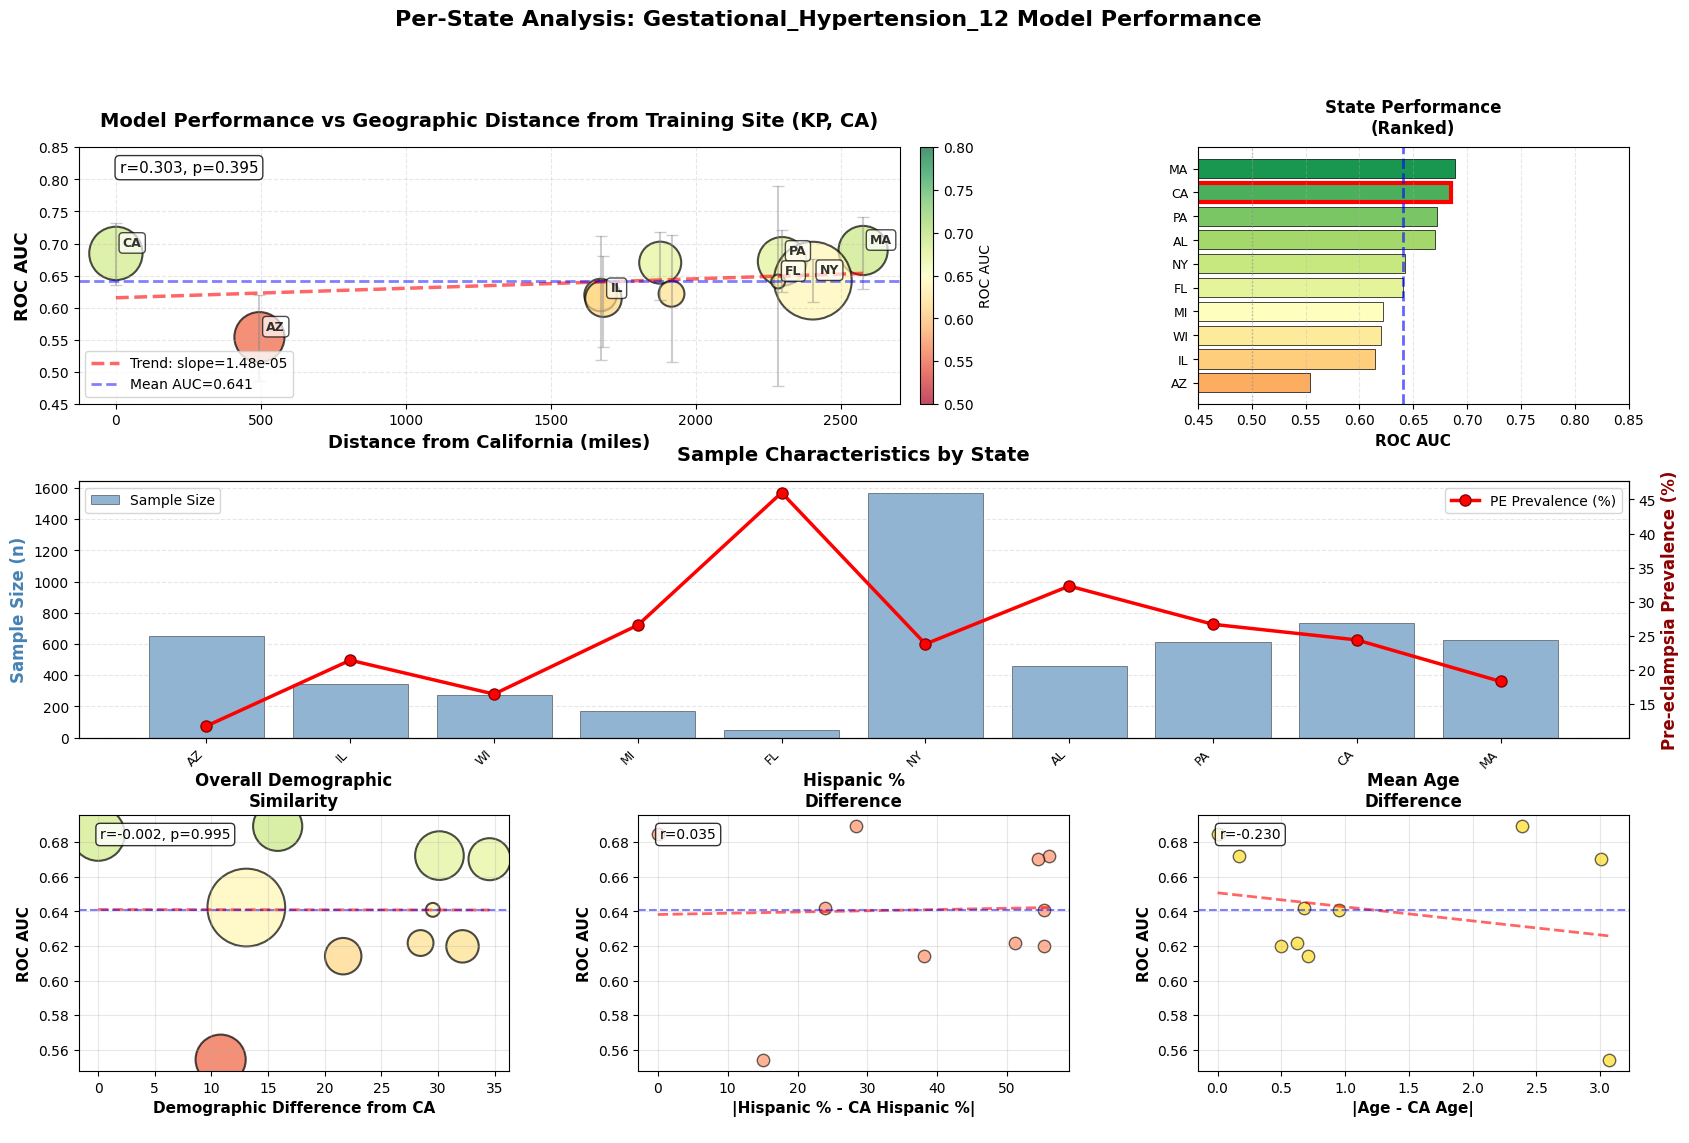

In [27]:

# # Create comprehensive figure with multiple subplots
# fig = plt.figure(figsize=(20, 12))
# gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# # PLOT 1: AUC vs Distance from California
# ax1 = fig.add_subplot(gs[0, :2])

# # Scatter plot with size by sample size
# scatter = ax1.scatter(state_results_df['distance_from_ca'], 
#                      state_results_df['roc_auc'],
#                      s=state_results_df['n_total']*2,  # Size by sample size
#                      c=state_results_df['roc_auc'],
#                      cmap='RdYlGn',
#                      alpha=0.7,
#                      edgecolors='black',
#                      linewidth=1.5,
#                      vmin=0.5, vmax=0.8)

# # Add error bars for confidence intervals
# ax1.errorbar(state_results_df['distance_from_ca'], 
#              state_results_df['roc_auc'],
#              yerr=[state_results_df['roc_auc'] - state_results_df['ci_lower'],
#                    state_results_df['ci_upper'] - state_results_df['roc_auc']],
#              fmt='none', ecolor='gray', alpha=0.4, capsize=4, linewidth=1.5)

# # Add state labels for key states
# highlight_states = ['CA', 'NY', 'TX', 'FL', 'MA', 'PA', 'IL', 'AZ']
# for _, row in state_results_df.iterrows():
#     if row['state'] in highlight_states:
#         ax1.annotate(row['state'], 
#                     (row['distance_from_ca'], row['roc_auc']),
#                     xytext=(5, 5), textcoords='offset points',
#                     fontsize=9, fontweight='bold', alpha=0.8,
#                     bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# # Calculate and plot regression line
# valid_mask = ~state_results_df['distance_from_ca'].isna()
# x_vals = state_results_df.loc[valid_mask, 'distance_from_ca']
# y_vals = state_results_df.loc[valid_mask, 'roc_auc']

# if len(x_vals) > 2:
#     z = np.polyfit(x_vals, y_vals, 1)
#     p = np.poly1d(z)
#     x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
#     ax1.plot(x_line, p(x_line), "r--", alpha=0.6, linewidth=2.5,
#             label=f'Trend: slope={z[0]:.2e}')
    
#     # Calculate correlation
#     corr, p_value = stats.pearsonr(x_vals, y_vals)
#     ax1.text(0.05, 0.95, f'r={corr:.3f}, p={p_value:.3f}',
#             transform=ax1.transAxes, fontsize=11, verticalalignment='top',
#             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# # Add reference line for overall AUC
# overall_auc_mean = state_results_df['roc_auc'].mean()
# ax1.axhline(y=overall_auc_mean, color='blue', linestyle='--', alpha=0.5, linewidth=2,
#            label=f'Mean AUC={overall_auc_mean:.3f}')

# ax1.set_xlabel('Distance from California (miles)', fontsize=13, fontweight='bold')
# ax1.set_ylabel('ROC AUC', fontsize=13, fontweight='bold')
# ax1.set_title('Model Performance vs Geographic Distance from Training Site (KP, CA)', 
#               fontsize=14, fontweight='bold', pad=15)
# ax1.legend(fontsize=10, loc='lower left')
# ax1.grid(True, alpha=0.3, linestyle='--')
# ax1.set_ylim([0.45, 0.85])
# cbar = plt.colorbar(scatter, ax=ax1, label='ROC AUC', pad=0.02)

# # PLOT 2: AUC by State (Ranked)
# ax2 = fig.add_subplot(gs[0, 2])

# state_results_sorted = state_results_df.sort_values('roc_auc', ascending=True)

# # Color bars by AUC value
# colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(state_results_sorted)))
# bars = ax2.barh(range(len(state_results_sorted)), 
#                 state_results_sorted['roc_auc'],
#                 color=colors,
#                 edgecolor='black',
#                 linewidth=0.5)

# # Highlight California if present
# ca_idx = list(state_results_sorted['state']).index('CA') if 'CA' in list(state_results_sorted['state']) else None
# if ca_idx is not None:
#     bars[ca_idx].set_edgecolor('red')
#     bars[ca_idx].set_linewidth(3)

# ax2.set_yticks(range(len(state_results_sorted)))
# ax2.set_yticklabels(state_results_sorted['state'], fontsize=9)
# ax2.axvline(x=overall_auc_mean, color='blue', linestyle='--', alpha=0.6, linewidth=2)
# ax2.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1)
# ax2.set_xlabel('ROC AUC', fontsize=11, fontweight='bold')
# ax2.set_title('State Performance\n(Ranked)', fontsize=12, fontweight='bold', pad=10)
# ax2.grid(True, alpha=0.3, axis='x', linestyle='--')
# ax2.set_xlim([0.45, 0.85])

# # PLOT 3: Sample Size and Prevalence by State
# ax3 = fig.add_subplot(gs[1, :])
# ax3_twin = ax3.twinx()

# x_pos = range(len(state_results_sorted))

# # Bar plot for sample size
# bars3 = ax3.bar(x_pos, state_results_sorted['n_total'], 
#                alpha=0.6, color='steelblue', edgecolor='black', linewidth=0.5,
#                label='Sample Size')

# # Line plot for prevalence
# line3 = ax3_twin.plot(x_pos, state_results_sorted['prevalence'], 
#                      'ro-', linewidth=2.5, markersize=8, 
#                      markeredgecolor='darkred', markeredgewidth=1,
#                      label='PE Prevalence (%)')

# ax3.set_xticks(x_pos)
# ax3.set_xticklabels(state_results_sorted['state'], rotation=45, ha='right', fontsize=9)
# ax3.set_ylabel('Sample Size (n)', fontsize=12, fontweight='bold', color='steelblue')
# ax3_twin.set_ylabel('Pre-eclampsia Prevalence (%)', fontsize=12, fontweight='bold', color='darkred')
# ax3.set_title('Sample Characteristics by State', fontsize=14, fontweight='bold', pad=15)
# ax3.legend(loc='upper left', fontsize=10)
# ax3_twin.legend(loc='upper right', fontsize=10)
# ax3.grid(True, alpha=0.3, axis='y', linestyle='--')

# # PLOT 4: Demographic Similarity vs AUC

# if ca_demographics is not None:
#     ax4 = fig.add_subplot(gs[2, 0])
    
#     scatter4 = ax4.scatter(state_results_df['demo_similarity_score'], 
#                           state_results_df['roc_auc'],
#                           s=state_results_df['n_total']*2,
#                           c=state_results_df['roc_auc'],
#                           cmap='RdYlGn',
#                           alpha=0.7,
#                           edgecolors='black',
#                           linewidth=1.5,
#                           vmin=0.5, vmax=0.8)
    
#     # Regression line
#     valid_data = state_results_df[['demo_similarity_score', 'roc_auc']].dropna()
#     if len(valid_data) > 2:
#         z = np.polyfit(valid_data['demo_similarity_score'], valid_data['roc_auc'], 1)
#         p = np.poly1d(z)
#         x_line = np.linspace(valid_data['demo_similarity_score'].min(), 
#                            valid_data['demo_similarity_score'].max(), 100)
#         corr, p_val = stats.pearsonr(valid_data['demo_similarity_score'], valid_data['roc_auc'])
#         ax4.plot(x_line, p(x_line), "r--", alpha=0.6, linewidth=2)
#         ax4.text(0.05, 0.95, f'r={corr:.3f}, p={p_val:.3f}', transform=ax4.transAxes,
#                 fontsize=10, verticalalignment='top',
#                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
#     ax4.set_xlabel('Demographic Difference from CA\n', 
#                    fontsize=11, fontweight='bold')
#     ax4.set_ylabel('ROC AUC', fontsize=11, fontweight='bold')
#     ax4.set_title('Overall Demographic\nSimilarity', fontsize=12, fontweight='bold')
#     ax4.grid(True, alpha=0.3)
#     ax4.axhline(y=overall_auc_mean, color='blue', linestyle='--', alpha=0.5, linewidth=1.5)

#     # PLOT 5: Hispanic % Difference vs AUC
#     ax5 = fig.add_subplot(gs[2, 1])
    
#     ax5.scatter(state_results_df['hispanic_diff'], state_results_df['roc_auc'], 
#                s=80, alpha=0.6, c='coral', edgecolors='black')
    
#     valid_data = state_results_df[['hispanic_diff', 'roc_auc']].dropna()
#     if len(valid_data) > 2:
#         z = np.polyfit(valid_data['hispanic_diff'], valid_data['roc_auc'], 1)
#         p = np.poly1d(z)
#         x_line = np.linspace(valid_data['hispanic_diff'].min(), 
#                            valid_data['hispanic_diff'].max(), 100)
#         corr, p_val = stats.pearsonr(valid_data['hispanic_diff'], valid_data['roc_auc'])
#         ax5.plot(x_line, p(x_line), "r--", alpha=0.6, linewidth=2)
#         ax5.text(0.05, 0.95, f'r={corr:.3f}', transform=ax5.transAxes,
#                 fontsize=10, verticalalignment='top',
#                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
#     ax5.set_xlabel('|Hispanic % - CA Hispanic %|', fontsize=11, fontweight='bold')
#     ax5.set_ylabel('ROC AUC', fontsize=11, fontweight='bold')
#     ax5.set_title('Hispanic %\nDifference', fontsize=12, fontweight='bold')
#     ax5.grid(True, alpha=0.3)
#     ax5.axhline(y=overall_auc_mean, color='blue', linestyle='--', alpha=0.5, linewidth=1.5)

#     # PLOT 6: Age Difference vs AUC
#     ax6 = fig.add_subplot(gs[2, 2])
    
#     ax6.scatter(state_results_df['age_diff'], state_results_df['roc_auc'], 
#                s=80, alpha=0.6, c='gold', edgecolors='black')
    
#     valid_data = state_results_df[['age_diff', 'roc_auc']].dropna()
#     if len(valid_data) > 2:
#         z = np.polyfit(valid_data['age_diff'], valid_data['roc_auc'], 1)
#         p = np.poly1d(z)
#         x_line = np.linspace(valid_data['age_diff'].min(), 
#                            valid_data['age_diff'].max(), 100)
#         corr, p_val = stats.pearsonr(valid_data['age_diff'], valid_data['roc_auc'])
#         ax6.plot(x_line, p(x_line), "r--", alpha=0.6, linewidth=2)
#         ax6.text(0.05, 0.95, f'r={corr:.3f}', transform=ax6.transAxes,
#                 fontsize=10, verticalalignment='top',
#                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
#     ax6.set_xlabel('|Age - CA Age|', fontsize=11, fontweight='bold')
#     ax6.set_ylabel('ROC AUC', fontsize=11, fontweight='bold')
#     ax6.set_title('Mean Age\nDifference', fontsize=12, fontweight='bold')
#     ax6.grid(True, alpha=0.3)
#     ax6.axhline(y=overall_auc_mean, color='blue', linestyle='--', alpha=0.5, linewidth=1.5)

# plt.suptitle(f'Per-State Analysis: {outcome} Model Performance', 
#              fontsize=16, fontweight='bold', y=0.995)

# # Save figure
# figure_filename = f'per_state_analysis_{outcome.replace(" ", "_").replace("-", "_")}.png'
# plt.savefig(figure_filename, dpi=300, bbox_inches='tight')
# print(f"\n Figure saved as: {figure_filename}")

# plt.show()






 Black % difference figure saved as: black_pct_difference_Gestational_Hypertension_12.png


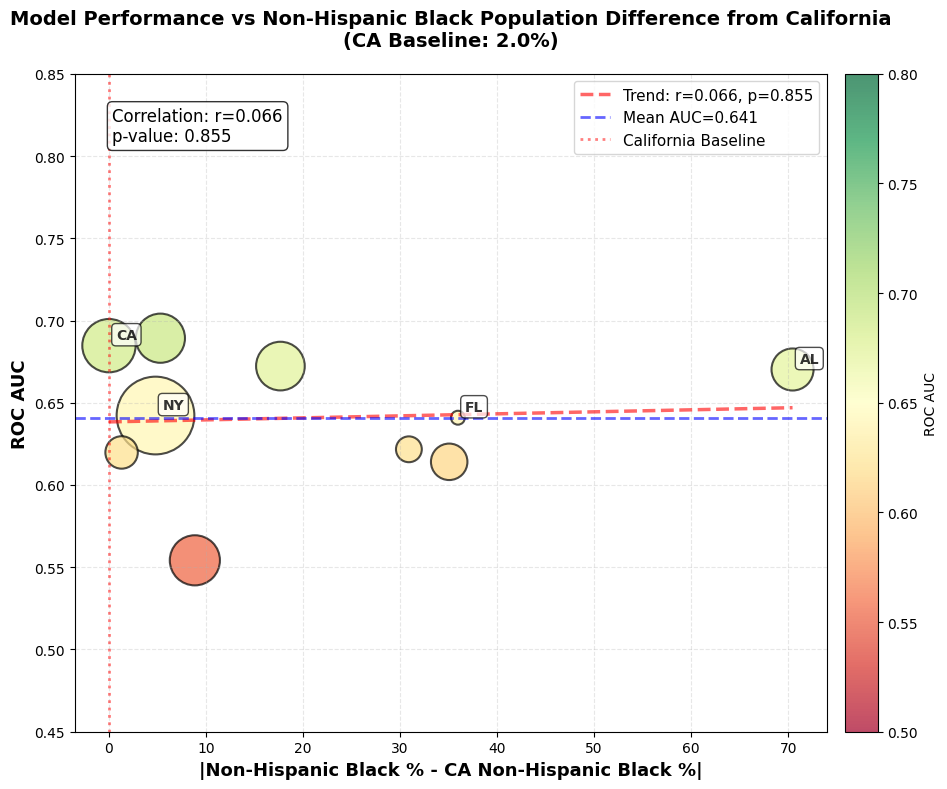

California NH Black %: 2.0%

States with higher NH Black % than CA:
  AL :  72.5% (diff: + 70.5%), AUC: 0.670
  FL :  38.0% (diff: + 36.0%), AUC: 0.641
  IL :  37.1% (diff: + 35.1%), AUC: 0.614
  MI :  32.9% (diff: + 30.9%), AUC: 0.622
  PA :  19.7% (diff: + 17.7%), AUC: 0.672
  AZ :  10.9% (diff: +  8.9%), AUC: 0.554
  MA :   7.3% (diff: +  5.3%), AUC: 0.689
  NY :   6.8% (diff: +  4.8%), AUC: 0.642

States with lower NH Black % than CA:
  WI :   0.7% (diff: -  1.3%), AUC: 0.620


In [28]:
# if ca_demographics is not None:
#     fig_black, ax_black = plt.subplots(figsize=(10, 8))
    
#     # Scatter plot for Black % difference
#     scatter_black = ax_black.scatter(state_results_df['black_diff'], 
#                                      state_results_df['roc_auc'],
#                                      s=state_results_df['n_total']*2,  # Size by sample size
#                                      c=state_results_df['roc_auc'],
#                                      cmap='RdYlGn',
#                                      alpha=0.7,
#                                      edgecolors='black',
#                                      linewidth=1.5,
#                                      vmin=0.5, vmax=0.8)
    
#     # Add state labels for key states with high/low Black populations
#     highlight_states_black = ['CA', 'NY', 'GA', 'FL', 'MD', 'VA', 'NC', 'SC', 'AL', 'MS', 'LA']
#     for _, row in state_results_df.iterrows():
#         if row['state'] in highlight_states_black:
#             ax_black.annotate(row['state'], 
#                             (row['black_diff'], row['roc_auc']),
#                             xytext=(5, 5), textcoords='offset points',
#                             fontsize=10, fontweight='bold', alpha=0.8,
#                             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    
#     # Regression line
#     valid_data = state_results_df[['black_diff', 'roc_auc']].dropna()
#     if len(valid_data) > 2:
#         z = np.polyfit(valid_data['black_diff'], valid_data['roc_auc'], 1)
#         p = np.poly1d(z)
#         x_line = np.linspace(valid_data['black_diff'].min(), 
#                            valid_data['black_diff'].max(), 100)
#         corr, p_val = stats.pearsonr(valid_data['black_diff'], valid_data['roc_auc'])
#         ax_black.plot(x_line, p(x_line), "r--", alpha=0.6, linewidth=2.5,
#                      label=f'Trend: r={corr:.3f}, p={p_val:.3f}')
        
#         # Add correlation text box
#         ax_black.text(0.05, 0.95, 
#                      f'Correlation: r={corr:.3f}\np-value: {p_val:.3f}',
#                      transform=ax_black.transAxes,
#                      fontsize=12, verticalalignment='top',
#                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
#     # Add reference line for overall AUC
#     ax_black.axhline(y=overall_auc_mean, color='blue', linestyle='--', 
#                     alpha=0.6, linewidth=2,
#                     label=f'Mean AUC={overall_auc_mean:.3f}')
    
#     # Add CA reference vertical line
#     ax_black.axvline(x=0, color='red', linestyle=':', 
#                     alpha=0.5, linewidth=2,
#                     label='California Baseline')
    
#     ax_black.set_xlabel('|Non-Hispanic Black % - CA Non-Hispanic Black %|', 
#                        fontsize=13, fontweight='bold')
#     ax_black.set_ylabel('ROC AUC', fontsize=13, fontweight='bold')
#     ax_black.set_title('Model Performance vs Non-Hispanic Black Population Difference from California\n' +
#                        f'(CA Baseline: {ca_demographics["NH_Black"]:.1f}%)', 
#                        fontsize=14, fontweight='bold', pad=20)
#     ax_black.legend(fontsize=11, loc='best')
#     ax_black.grid(True, alpha=0.3, linestyle='--')
#     ax_black.set_ylim([0.45, 0.85])
    
#     # Add colorbar
#     cbar_black = plt.colorbar(scatter_black, ax=ax_black, label='ROC AUC', pad=0.02)
    
#     plt.tight_layout()
    
#     # Save figure
#     figure_black_filename = f'black_pct_difference_{outcome.replace(" ", "_").replace("-", "_")}.png'
#     plt.savefig(figure_black_filename, dpi=300, bbox_inches='tight')
#     print(f"\n Black % difference figure saved as: {figure_black_filename}")
    
#     plt.show()
    
#     print(f"California NH Black %: {ca_demographics['NH_Black']:.1f}%")
#     print(f"\nStates with higher NH Black % than CA:")
#     higher_black = state_results_df[state_results_df['pct_nh_black'] > ca_demographics['NH_Black']].sort_values('pct_nh_black', ascending=False)
#     if len(higher_black) > 0:
#         for _, row in higher_black.iterrows():
#             print(f"  {row['state']:3s}: {row['pct_nh_black']:5.1f}% (diff: +{row['black_diff']:5.1f}%), AUC: {row['roc_auc']:.3f}")
#     else:
#         print("  None")
    
#     print(f"\nStates with lower NH Black % than CA:")
#     lower_black = state_results_df[state_results_df['pct_nh_black'] < ca_demographics['NH_Black']].sort_values('pct_nh_black', ascending=True)
#     if len(lower_black) > 0:
#         for _, row in lower_black.head(10).iterrows():
#             print(f"  {row['state']:3s}: {row['pct_nh_black']:5.1f}% (diff: -{row['black_diff']:5.1f}%), AUC: {row['roc_auc']:.3f}")
#     else:
#         print("  None")


 Demographic comparison figure saved as: demographic_comparison_Gestational_Hypertension_12.png


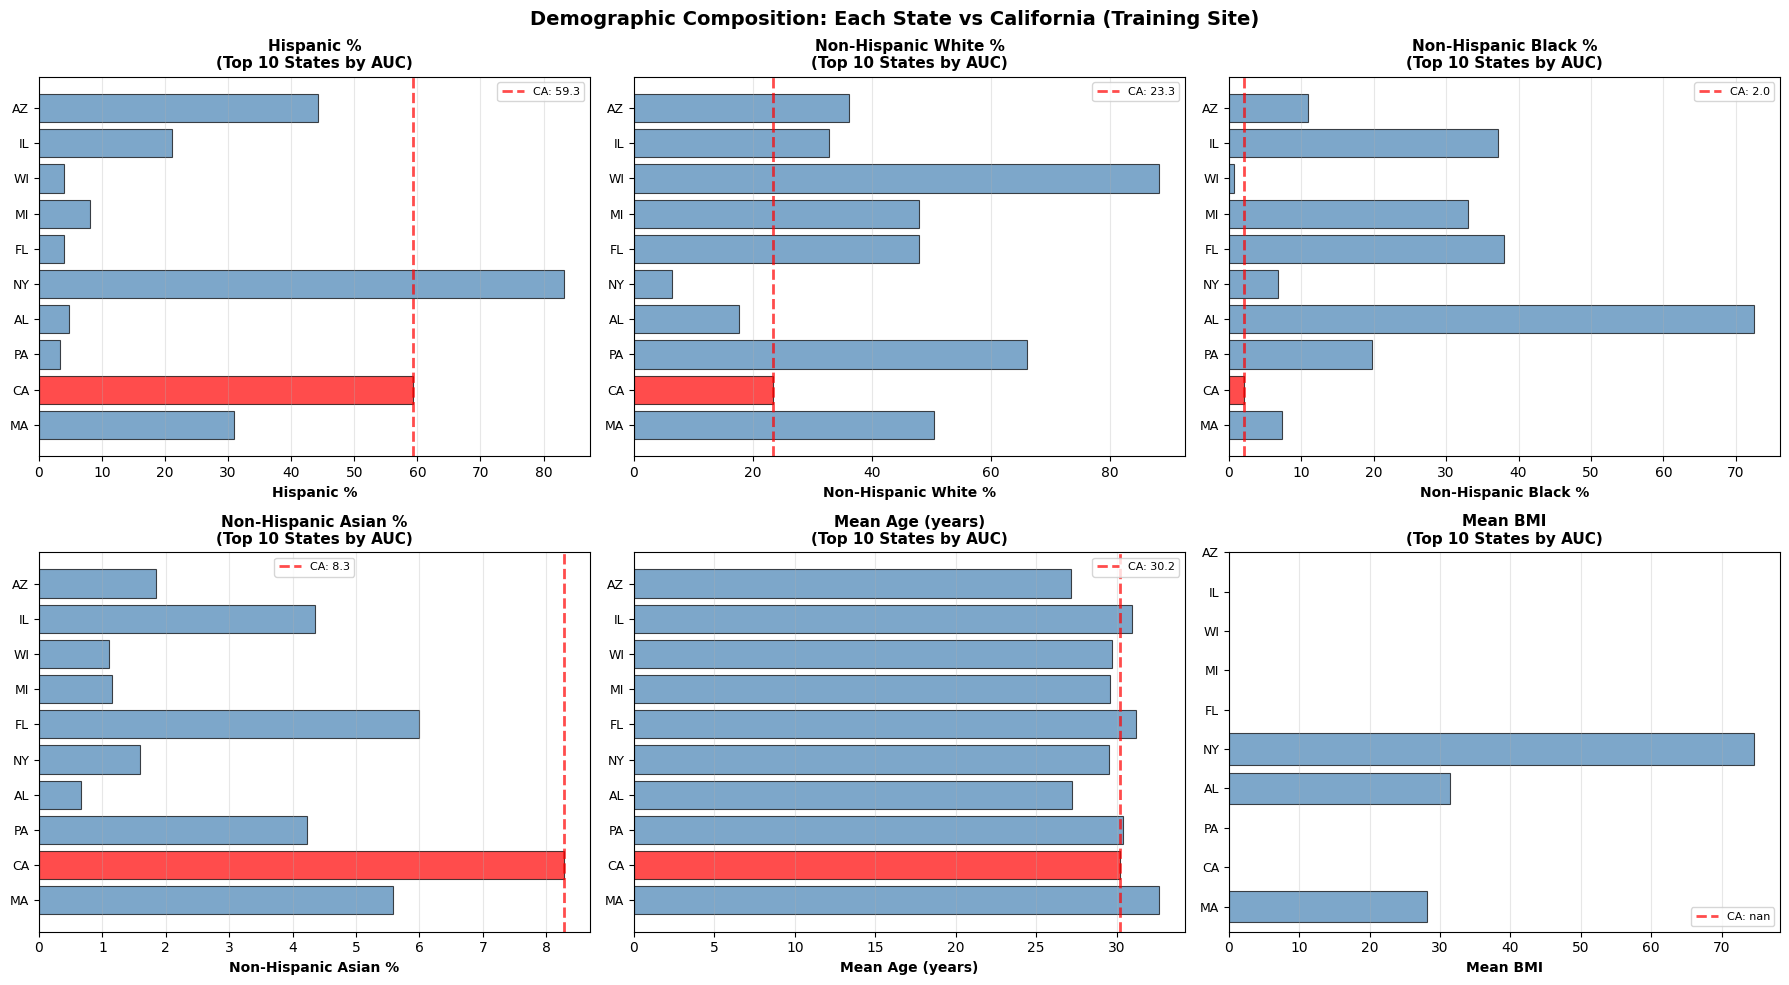

In [29]:
# if ca_demographics is not None:
    
#     fig2, axes = plt.subplots(2, 3, figsize=(18, 10))
#     fig2.suptitle('Demographic Composition: Each State vs California (Training Site)', 
#                   fontsize=14, fontweight='bold')
    
#     # Get states sorted by performance
#     top_states = state_results_df.nlargest(10, 'roc_auc')['state'].tolist()
    
#     demographic_vars = [
#         ('pct_hispanic', 'Hispanic %', ca_demographics['Hispanic']),
#         ('pct_nh_white', 'Non-Hispanic White %', ca_demographics['NH_White']),
#         ('pct_nh_black', 'Non-Hispanic Black %', ca_demographics['NH_Black']),
#         ('pct_nh_asian', 'Non-Hispanic Asian %', ca_demographics['NH_Asian']),
#         ('mean_age', 'Mean Age (years)', ca_demographics['mean_age']),
#         ('mean_bmi', 'Mean BMI', ca_demographics['mean_bmi'])
#     ]
    
#     for idx, (var, label, ca_value) in enumerate(demographic_vars):
#         ax = axes[idx // 3, idx % 3]
        
#         # Create bar plot
#         state_subset = state_results_df[state_results_df['state'].isin(top_states)].copy()
#         state_subset = state_subset.sort_values('roc_auc', ascending=False)
        
#         colors_bar = ['red' if s == 'CA' else 'steelblue' for s in state_subset['state']]
        
#         bars = ax.barh(range(len(state_subset)), state_subset[var], 
#                       color=colors_bar, alpha=0.7, edgecolor='black', linewidth=0.8)
        
#         # Add CA reference line
#         ax.axvline(x=ca_value, color='red', linestyle='--', linewidth=2, 
#                   alpha=0.7, label=f'CA: {ca_value:.1f}')
        
#         ax.set_yticks(range(len(state_subset)))
#         ax.set_yticklabels(state_subset['state'], fontsize=9)
#         ax.set_xlabel(label, fontsize=10, fontweight='bold')
#         ax.set_title(f'{label}\n(Top 10 States by AUC)', fontsize=11, fontweight='bold')
#         ax.legend(fontsize=8)
#         ax.grid(True, alpha=0.3, axis='x')
    
#     plt.tight_layout()
    
#     figure2_filename = f'demographic_comparison_{outcome.replace(" ", "_").replace("-", "_")}.png'
#     plt.savefig(figure2_filename, dpi=300, bbox_inches='tight')
#     print(f"\n Demographic comparison figure saved as: {figure2_filename}")
    
#     plt.show()


 Confidence interval figure saved as: confidence_intervals_Gestational_Hypertension_12.png


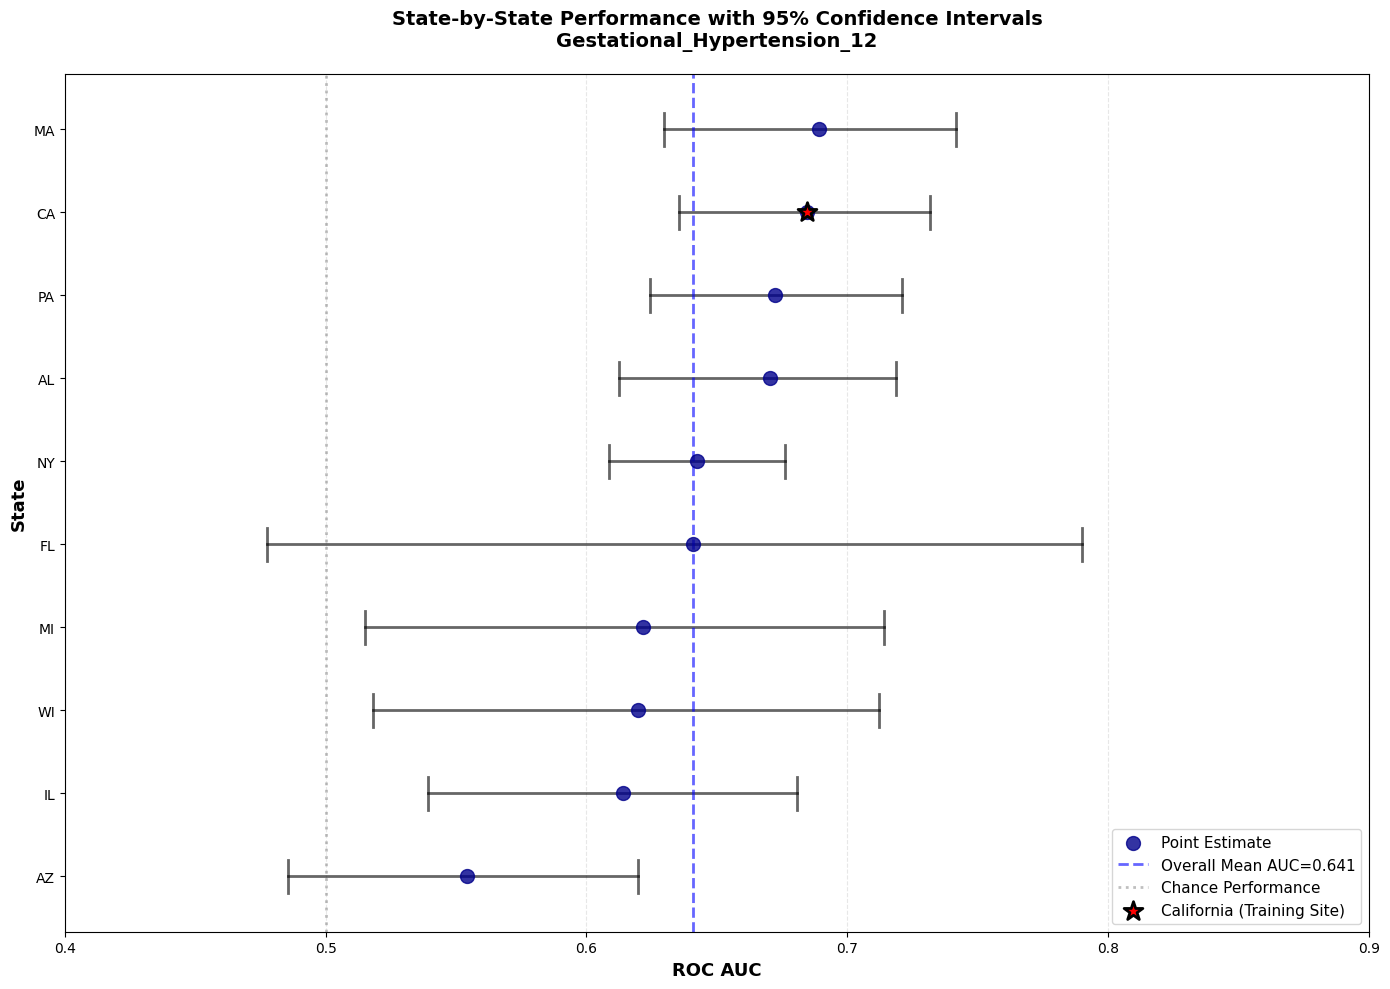

In [30]:
# fig3, ax = plt.subplots(figsize=(14, 10))

# # Sort by AUC
# state_results_sorted_ci = state_results_df.sort_values('roc_auc', ascending=True)

# y_positions = range(len(state_results_sorted_ci))

# # Plot point estimates
# ax.scatter(state_results_sorted_ci['roc_auc'], y_positions, 
#           s=100, c='darkblue', alpha=0.8, zorder=3, label='Point Estimate')

# # Plot confidence intervals
# for idx, (_, row) in enumerate(state_results_sorted_ci.iterrows()):
#     ax.plot([row['ci_lower'], row['ci_upper']], [idx, idx], 
#            'k-', linewidth=2, alpha=0.6, zorder=2)
#     ax.plot([row['ci_lower'], row['ci_lower']], [idx-0.2, idx+0.2], 
#            'k-', linewidth=2, alpha=0.6, zorder=2)
#     ax.plot([row['ci_upper'], row['ci_upper']], [idx-0.2, idx+0.2], 
#            'k-', linewidth=2, alpha=0.6, zorder=2)

# # Add reference lines
# ax.axvline(x=overall_auc_mean, color='blue', linestyle='--', 
#           linewidth=2, alpha=0.6, label=f'Overall Mean AUC={overall_auc_mean:.3f}')
# ax.axvline(x=0.5, color='gray', linestyle=':', 
#           linewidth=2, alpha=0.5, label='Chance Performance')

# # Highlight California if present
# ca_idx = list(state_results_sorted_ci['state']).index('CA') if 'CA' in list(state_results_sorted_ci['state']) else None
# if ca_idx is not None:
#     ax.scatter(state_results_sorted_ci.iloc[ca_idx]['roc_auc'], ca_idx,
#               s=200, c='red', marker='*', edgecolors='black', linewidth=2,
#               zorder=4, label='California (Training Site)')

# ax.set_yticks(y_positions)
# ax.set_yticklabels(state_results_sorted_ci['state'], fontsize=10)
# ax.set_xlabel('ROC AUC', fontsize=13, fontweight='bold')
# ax.set_ylabel('State', fontsize=13, fontweight='bold')
# ax.set_title(f'State-by-State Performance with 95% Confidence Intervals\n{outcome}', 
#             fontsize=14, fontweight='bold', pad=20)
# ax.legend(fontsize=11, loc='lower right')
# ax.grid(True, alpha=0.3, axis='x', linestyle='--')
# ax.set_xlim([0.4, 0.9])

# plt.tight_layout()

# figure3_filename = f'confidence_intervals_{outcome.replace(" ", "_").replace("-", "_")}.png'
# plt.savefig(figure3_filename, dpi=300, bbox_inches='tight')
# print(f"\n Confidence interval figure saved as: {figure3_filename}")

# plt.show()


In [31]:

# # Compute Per-State Feature Missingness Profiles


# from scipy.spatial.distance import cosine, euclidean
# from scipy import stats

# print("=" * 70)
# print("FEATURE COMPLETENESS ANALYSIS")
# print("=" * 70)

# # Use the UN-SCALED data to get true missingness (before MinMaxScaler fills things in)
# # We need to go back to df_external before scaling
# # Reconstruct feature-only dataframe (drop person_id_x)
# feature_cols = [f for f in feats_to_train if f in df.columns or f in df_external.columns]

# # Get the feature matrix aligned with eval set indices
# # df_eval_full has the state info; x_eval has the scaled features
# # We need the RAW (pre-scaling) features to measure true missingness

# # Build raw feature matrix from df using eval indices
# eval_indices = df_eval_full.index
# existing_feats = [f for f in feats_to_train if f in df.columns]
# df_raw_features = df.loc[eval_indices, existing_feats].copy()

# print(f"Raw feature matrix shape: {df_raw_features.shape}")
# print(f"Overall missingness rate: {df_raw_features.isna().mean().mean():.3f}")

# # Compute per-state missingness profiles
# states_analyzed = state_results_df['state'].tolist()

# missingness_profiles = {}
# completeness_profiles = {}

# for state in states_analyzed:
#     state_mask = df_eval_full.loc[eval_indices, 'state_clean'] == state
#     state_raw = df_raw_features.loc[state_mask]
#     miss_profile = state_raw.isna().mean()  # missingness rate per feature
#     comp_profile = state_raw.notna().mean()  # completeness rate per feature
#     missingness_profiles[state] = miss_profile
#     completeness_profiles[state] = comp_profile

# # Create missingness profile dataframe
# miss_df = pd.DataFrame(missingness_profiles).T
# comp_df = pd.DataFrame(completeness_profiles).T

# print(f"\nPer-state missingness profiles computed for {len(states_analyzed)} states")
# print(f"Features tracked: {len(feats_to_train)}")

# # Show overall completeness by state
# print("\nOverall Feature Completeness by State:")
# for state in states_analyzed:
#     overall_comp = comp_df.loc[state].mean() * 100
#     print(f"  {state:3s}: {overall_comp:.1f}% features available on average")



FEATURE COMPLETENESS ANALYSIS
Raw feature matrix shape: (5594, 148)
Overall missingness rate: 0.470

Per-state missingness profiles computed for 10 states
Features tracked: 214

Overall Feature Completeness by State:
  MA : 54.0% features available on average
  CA : 49.4% features available on average
  PA : 55.9% features available on average
  AL : 56.1% features available on average
  NY : 55.7% features available on average
  FL : 55.2% features available on average
  MI : 57.1% features available on average
  WI : 44.7% features available on average
  IL : 54.0% features available on average
  AZ : 46.7% features available on average


In [32]:
# #Feature Similarity Distances from California

# print("\n" + "=" * 70)
# print("FEATURE SIMILARITY TO CALIFORNIA (TRAINING SITE)")
# print("=" * 70)

# ca_miss = missingness_profiles['CA']
# ca_comp = completeness_profiles['CA']

# feature_similarity = {}

# for state in states_analyzed:
#     state_miss = missingness_profiles[state]
#     state_comp = completeness_profiles[state]

#     # 1. Cosine distance of missingness profiles
#     # Handle edge case where one vector is all zeros
#     if state_miss.sum() == 0 and ca_miss.sum() == 0:
#         cos_dist = 0.0
#     elif state_miss.sum() == 0 or ca_miss.sum() == 0:
#         cos_dist = 1.0
#     else:
#         cos_dist = cosine(state_miss, ca_miss)

#     # 2. L1 (Manhattan) distance: mean absolute difference in missingness rates
#     l1_dist = np.abs(state_miss - ca_miss).mean()

#     # 3. L2 (Euclidean) distance of missingness vectors
#     l2_dist = euclidean(state_miss, ca_miss)

#     # 4. Max absolute difference (worst single feature gap)
#     max_diff = np.abs(state_miss - ca_miss).max()
#     worst_feature = np.abs(state_miss - ca_miss).idxmax()

#     feature_similarity[state] = {
#         'cosine_distance': cos_dist,
#         'l1_mean_abs_diff': l1_dist,
#         'l2_distance': l2_dist,
#         'max_single_feature_diff': max_diff,
#         'worst_feature': worst_feature,
#         'overall_completeness': state_comp.mean() * 100,
#     }

# feat_sim_df = pd.DataFrame(feature_similarity).T
# feat_sim_df.index.name = 'state'

# print("\nFeature Similarity Metrics (distance from CA, lower = more similar):")
# print(feat_sim_df[['cosine_distance', 'l1_mean_abs_diff', 'overall_completeness',
#                     'worst_feature']].to_string())



FEATURE SIMILARITY TO CALIFORNIA (TRAINING SITE)

Feature Similarity Metrics (distance from CA, lower = more similar):
      cosine_distance l1_mean_abs_diff overall_completeness worst_feature
state                                                                    
MA           0.041948         0.103392            53.998017     PPREG_BMI
CA                  0              0.0             49.41142    pp_ALT_avg
PA           0.033785         0.104208            55.884101    ep_ANC_avg
AL           0.017507         0.073427            56.088457     PPREG_BMI
NY            0.01516          0.07948             55.65091    ep_HGB_std
FL           0.087806         0.175118            55.202703    pp_sbp_avg
MI           0.033667         0.116234            57.096547    ep_WBC_avg
WI           0.025523          0.09991             44.67132    ep_HGB_avg
IL           0.005438         0.051709            54.024677    pp_ANC_avg
AZ           0.056248          0.10958            46.693127    pp_

In [33]:
# # Merge with State Performance Results

# state_results_df = state_results_df.set_index('state')
# for col in ['cosine_distance', 'l1_mean_abs_diff', 'l2_distance',
#             'max_single_feature_diff', 'overall_completeness']:
#     state_results_df[col] = feat_sim_df[col]
# state_results_df = state_results_df.reset_index()

# print("\nMerged feature similarity metrics into state results")




Merged feature similarity metrics into state results


In [34]:
# # Correlation Analysis - Feature Similarity vs AUC

# print("\n" + "=" * 70)
# print("CORRELATION ANALYSIS: FEATURE SIMILARITY vs MODEL PERFORMANCE")
# print("=" * 70)

# similarity_metrics = {
#     'cosine_distance': 'Cosine Distance (Missingness Profile)',
#     'l1_mean_abs_diff': 'Mean Absolute Missingness Difference',
#     'l2_distance': 'Euclidean Distance (Missingness Profile)',
#     'overall_completeness': 'Overall Feature Completeness (%)',
#     'demo_similarity_score': 'Demographic Dissimilarity (existing)',
#     'distance_from_ca': 'Geographic Distance (existing)',
# }

# correlation_results = {}

# for metric, label in similarity_metrics.items():
#     if metric not in state_results_df.columns:
#         continue
#     valid = state_results_df[[metric, 'roc_auc']].dropna()
#     if len(valid) > 2:
#         corr, p_val = stats.pearsonr(valid[metric], valid['roc_auc'])
#         correlation_results[metric] = {'label': label, 'r': corr, 'p': p_val, 'n': len(valid)}
#         sig = "***" if p_val < 0.01 else "**" if p_val < 0.05 else "*" if p_val < 0.1 else ""
#         print(f"\n  {label}:")
#         print(f"    r = {corr:.3f}, p = {p_val:.3f} {sig}")

# print("\n(*** p<0.01, ** p<0.05, * p<0.1)")




CORRELATION ANALYSIS: FEATURE SIMILARITY vs MODEL PERFORMANCE

  Cosine Distance (Missingness Profile):
    r = -0.271, p = 0.449 

  Mean Absolute Missingness Difference:
    r = -0.281, p = 0.432 

  Euclidean Distance (Missingness Profile):
    r = -0.360, p = 0.306 

  Overall Feature Completeness (%):
    r = 0.431, p = 0.214 

  Demographic Dissimilarity (existing):
    r = -0.002, p = 0.995 

  Geographic Distance (existing):
    r = 0.303, p = 0.395 

(*** p<0.01, ** p<0.05, * p<0.1)


In [35]:
# #Top-Feature Availability Analysis

# print("\n" + "=" * 70)
# print("TOP GHTN FEATURE AVAILABILITY BY STATE")
# print("=" * 70)

# # Top features from SHAP for GHTN_12w model
# top_ghtn_features = ['ep_sbp_avg', 'pp_sbp_avg', 'ep_dbp_avg', 'pp_dbp_avg',
#                      'PPREG_BMI', 'ep_sbp_max', 'pp_sbp_max', 'ep_dbp_max',
#                      'pp_dbp_max', 'ep_hr_avg', 'pp_hr_avg']

# # Filter to features that exist in the data
# top_ghtn_available = [f for f in top_ghtn_features if f in df_raw_features.columns]
# print(f"Analyzing {len(top_ghtn_available)} top GHTN features: {top_ghtn_available}")

# top_feat_avail = {}
# for state in states_analyzed:
#     state_mask = df_eval_full.loc[eval_indices, 'state_clean'] == state
#     state_raw = df_raw_features.loc[state_mask]
#     avail = state_raw[top_ghtn_available].notna().mean()
#     top_feat_avail[state] = {
#         'mean_top_feat_completeness': avail.mean() * 100,
#         **{f'{f}_avail': avail[f] * 100 for f in top_ghtn_available}
#     }

# top_feat_df = pd.DataFrame(top_feat_avail).T
# top_feat_df.index.name = 'state'

# print("\nTop Feature Completeness by State:")
# print(f"{'State':<6} {'Mean Top Feat %':>16} {'ep_sbp_avg %':>14} {'pp_sbp_avg %':>14} {'PPREG_BMI %':>14}")
# for state in states_analyzed:
#     row = top_feat_df.loc[state]
#     ep_sbp = row.get('ep_sbp_avg_avail', np.nan)
#     pp_sbp = row.get('pp_sbp_avg_avail', np.nan)
#     bmi = row.get('PPREG_BMI_avail', np.nan)
#     print(f"  {state:<4} {row['mean_top_feat_completeness']:>14.1f}% {ep_sbp:>13.1f}% {pp_sbp:>13.1f}% {bmi:>13.1f}%")

# # Add to state results
# state_results_df = state_results_df.set_index('state')
# state_results_df['top_feat_completeness'] = top_feat_df['mean_top_feat_completeness']
# state_results_df = state_results_df.reset_index()

# # Correlation with top-feature availability
# valid = state_results_df[['top_feat_completeness', 'roc_auc']].dropna()
# if len(valid) > 2:
#     corr, p_val = stats.pearsonr(valid['top_feat_completeness'], valid['roc_auc'])
#     print(f"\nTop Feature Completeness vs AUC:")
#     print(f"  r = {corr:.3f}, p = {p_val:.3f}")
#     correlation_results['top_feat_completeness'] = {
#         'label': 'Top GHTN Feature Completeness',
#         'r': corr, 'p': p_val, 'n': len(valid)
#     }



TOP GHTN FEATURE AVAILABILITY BY STATE
Analyzing 11 top GHTN features: ['ep_sbp_avg', 'pp_sbp_avg', 'ep_dbp_avg', 'pp_dbp_avg', 'PPREG_BMI', 'ep_sbp_max', 'pp_sbp_max', 'ep_dbp_max', 'pp_dbp_max', 'ep_hr_avg', 'pp_hr_avg']

Top Feature Completeness by State:
State   Mean Top Feat %   ep_sbp_avg %   pp_sbp_avg %    PPREG_BMI %
  MA             61.7%          58.7%          78.3%          76.9%
  CA             61.2%          59.7%          77.7%           0.0%
  PA             57.8%          71.5%          62.2%           0.0%
  AL             78.0%          69.2%          86.7%          90.4%
  NY             66.8%          79.9%          73.8%           3.4%
  FL             23.5%           4.0%          22.0%           0.0%
  MI             77.5%          82.7%          93.1%           0.0%
  WI             39.4%          43.6%          49.8%           0.0%
  IL             65.3%          67.0%          79.7%           0.0%
  AZ             17.0%           3.1%          15.5%       

In [36]:
# # Feature Category Missingness Breakdown

# print("\n" + "=" * 70)
# print("MISSINGNESS BY FEATURE CATEGORY")
# print("=" * 70)

# # Categorize features
# pp_lab_feats = [f for f in feats_to_train if f.startswith('pp_') and
#                 not any(f.startswith(p) for p in ['pp_hr', 'pp_sbp', 'pp_dbp'])]
# ep_lab_feats = [f for f in feats_to_train if f.startswith('ep_') and
#                 not any(f.startswith(p) for p in ['ep_hr', 'ep_sbp', 'ep_dbp'])]
# pp_vital_feats = [f for f in feats_to_train if any(f.startswith(p) for p in ['pp_hr', 'pp_sbp', 'pp_dbp'])]
# ep_vital_feats = [f for f in feats_to_train if any(f.startswith(p) for p in ['ep_hr', 'ep_sbp', 'ep_dbp'])]
# clinical_feats = [f for f in feats_to_train if not f.startswith(('pp_', 'ep_'))]

# categories = {
#     'Pre-preg Labs': pp_lab_feats,
#     'Early-preg Labs': ep_lab_feats,
#     'Pre-preg Vitals': pp_vital_feats,
#     'Early-preg Vitals': ep_vital_feats,
#     'Clinical/Demo': clinical_feats,
# }

# # Filter to features that actually exist in the raw data
# categories_filtered = {}
# for cat, feats in categories.items():
#     existing = [f for f in feats if f in df_raw_features.columns]
#     if existing:
#         categories_filtered[cat] = existing

# cat_completeness = {}
# for state in states_analyzed:
#     state_mask = df_eval_full.loc[eval_indices, 'state_clean'] == state
#     state_raw = df_raw_features.loc[state_mask]
#     cat_completeness[state] = {}
#     for cat, feats in categories_filtered.items():
#         cat_completeness[state][cat] = state_raw[feats].notna().mean().mean() * 100

# cat_comp_df = pd.DataFrame(cat_completeness).T

# print("\nCompleteness (%) by Feature Category and State:\n")
# print(cat_comp_df.round(1).to_string())

# # Compute per-category distance from CA
# ca_cat = cat_comp_df.loc['CA']
# cat_distance = {}
# for state in states_analyzed:
#     if state == 'CA':
#         cat_distance[state] = 0.0
#     else:
#         cat_distance[state] = np.abs(cat_comp_df.loc[state] - ca_cat).mean()

# state_results_df = state_results_df.set_index('state')
# state_results_df['category_completeness_dist'] = pd.Series(cat_distance)
# state_results_df = state_results_df.reset_index()




MISSINGNESS BY FEATURE CATEGORY

Completeness (%) by Feature Category and State:

    Pre-preg Labs  Early-preg Labs  Pre-preg Vitals  Early-preg Vitals  Clinical/Demo
MA           47.7             24.8             65.2               36.8           99.4
CA           34.1             17.7             75.1               52.5           97.2
PA           49.2             29.0             62.0               48.8           97.2
AL           45.9             21.3             85.2               61.0           99.7
NY           38.8             31.5             68.4               67.9           97.3
FL           61.1             27.0             44.3               22.0           97.2
MI           44.5             24.5             90.6               69.1           97.2
WI           30.9             18.5             44.8               33.1           97.2
IL           41.9             22.9             78.1               58.8           97.2
AZ           45.1             19.1             34.6      


Feature similarity figure saved as: feature_similarity_analysis_Gestational_Hypertension_12.png


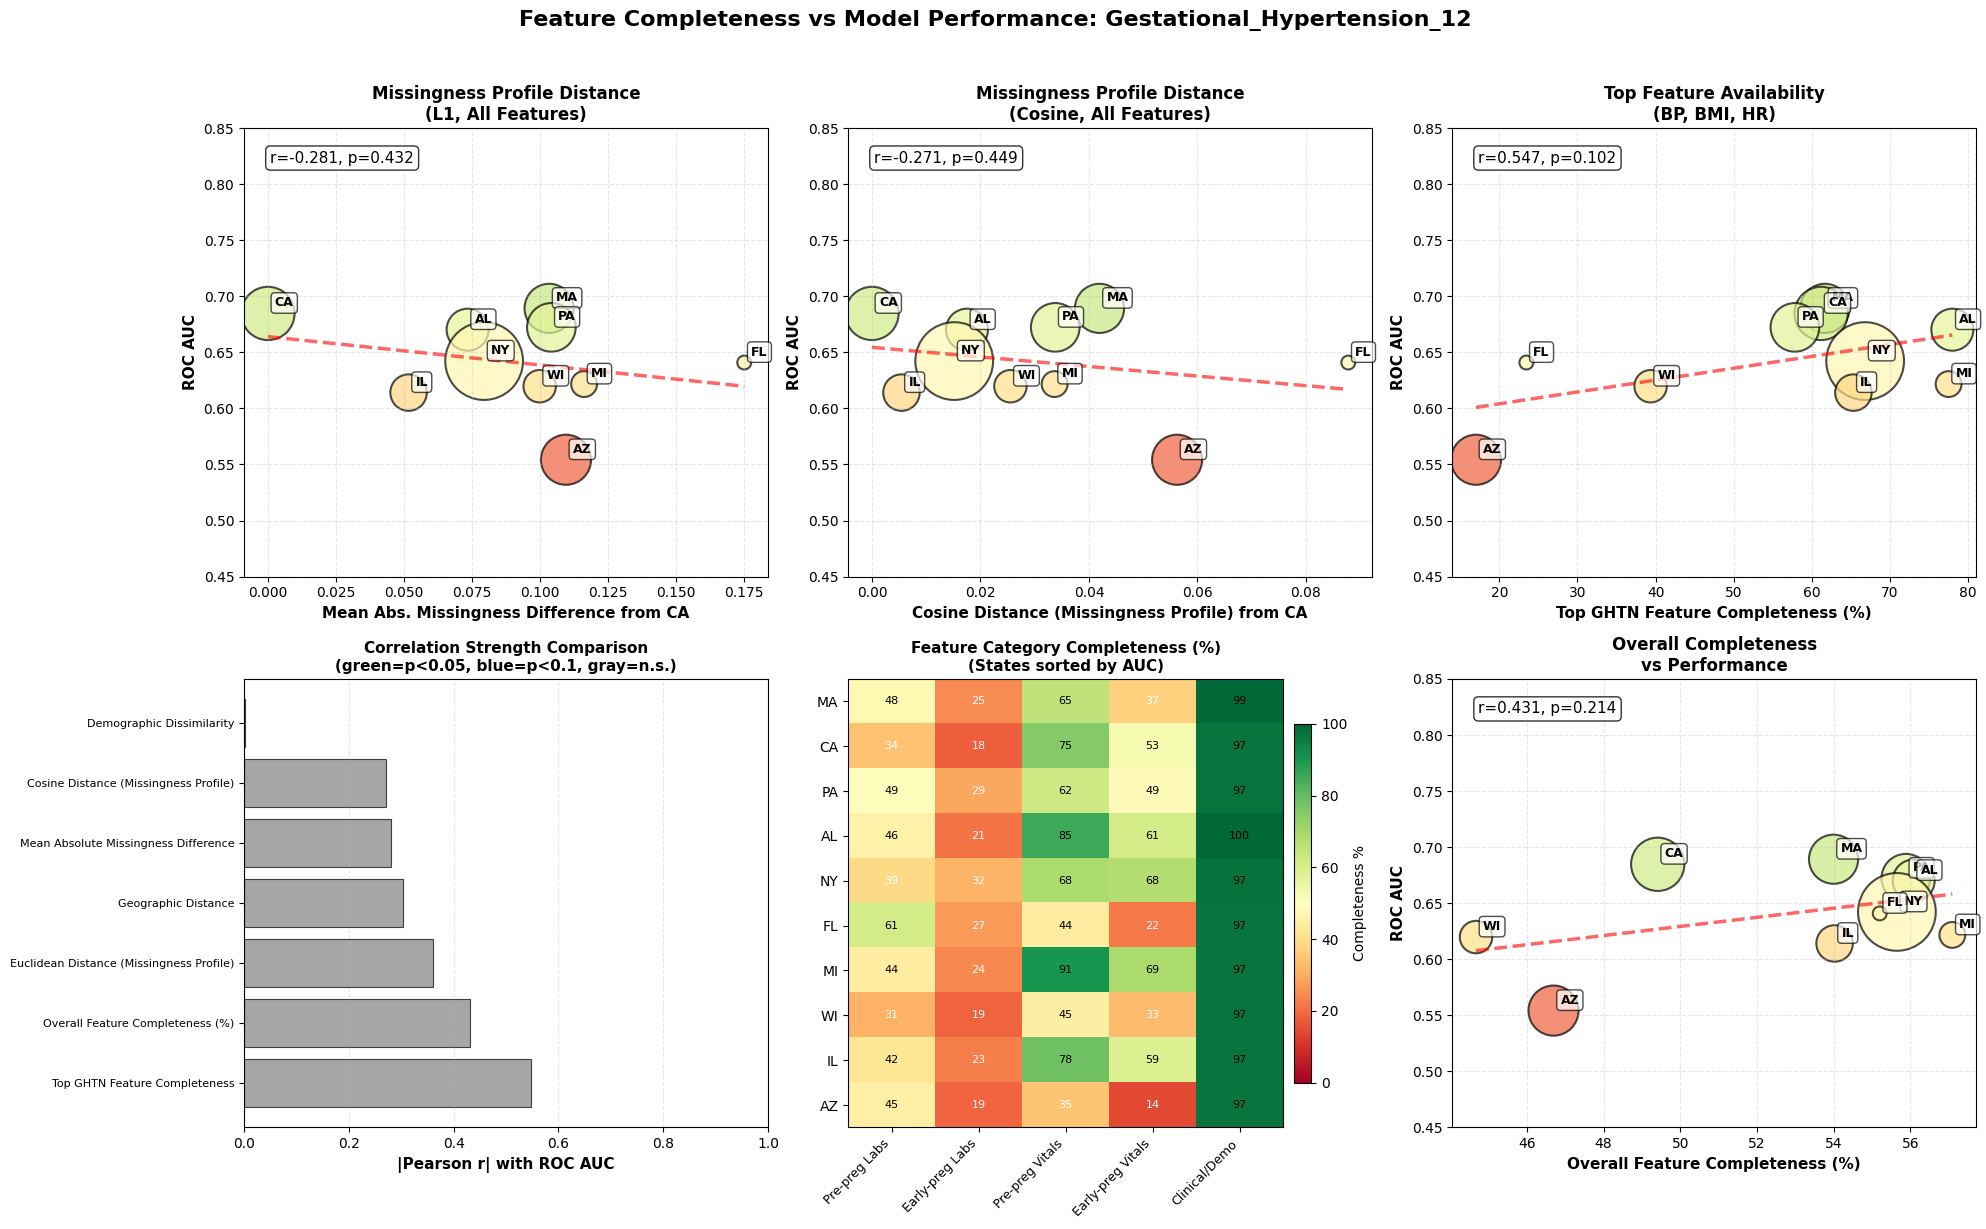

In [37]:
# # Ensure numeric dtypes for plotting
# numeric_cols = ['l1_mean_abs_diff', 'cosine_distance', 'l2_distance',
#                 'overall_completeness', 'top_feat_completeness', 
#                 'max_single_feature_diff', 'category_completeness_dist',
#                 'roc_auc', 'ci_lower', 'ci_upper', 'n_total']
# for col in numeric_cols:
#     if col in state_results_df.columns:
#         state_results_df[col] = pd.to_numeric(state_results_df[col], errors='coerce')
        
# fig_feat, axes = plt.subplots(2, 3, figsize=(20, 12))
# fig_feat.suptitle(f'Feature Completeness vs Model Performance: {outcome}',
#                   fontsize=16, fontweight='bold', y=1.02)

# # --- Plot 1: Missingness L1 distance vs AUC ---
# ax = axes[0, 0]
# x_data = state_results_df['l1_mean_abs_diff']
# y_data = state_results_df['roc_auc']
# sizes = state_results_df['n_total'] * 2

# scatter = ax.scatter(x_data, y_data, s=sizes, c=y_data, cmap='RdYlGn',
#                      alpha=0.7, edgecolors='black', linewidth=1.5, vmin=0.5, vmax=0.8)

# for _, row in state_results_df.iterrows():
#     ax.annotate(row['state'], (row['l1_mean_abs_diff'], row['roc_auc']),
#                 xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold',
#                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# valid = state_results_df[['l1_mean_abs_diff', 'roc_auc']].dropna()
# if len(valid) > 2:
#     z = np.polyfit(valid['l1_mean_abs_diff'], valid['roc_auc'], 1)
#     p = np.poly1d(z)
#     x_line = np.linspace(valid['l1_mean_abs_diff'].min(), valid['l1_mean_abs_diff'].max(), 100)
#     ax.plot(x_line, p(x_line), "r--", alpha=0.6, linewidth=2.5)
#     corr, p_val = stats.pearsonr(valid['l1_mean_abs_diff'], valid['roc_auc'])
#     ax.text(0.05, 0.95, f'r={corr:.3f}, p={p_val:.3f}',
#             transform=ax.transAxes, fontsize=11, verticalalignment='top',
#             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ax.set_xlabel('Mean Abs. Missingness Difference from CA', fontsize=11, fontweight='bold')
# ax.set_ylabel('ROC AUC', fontsize=11, fontweight='bold')
# ax.set_title('Missingness Profile Distance\n(L1, All Features)', fontsize=12, fontweight='bold')
# ax.grid(True, alpha=0.3, linestyle='--')
# ax.set_ylim([0.45, 0.85])

# # --- Plot 2: Cosine distance vs AUC ---
# ax = axes[0, 1]
# x_data = state_results_df['cosine_distance']

# scatter2 = ax.scatter(x_data, y_data, s=sizes, c=y_data, cmap='RdYlGn',
#                       alpha=0.7, edgecolors='black', linewidth=1.5, vmin=0.5, vmax=0.8)

# for _, row in state_results_df.iterrows():
#     ax.annotate(row['state'], (row['cosine_distance'], row['roc_auc']),
#                 xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold',
#                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# valid = state_results_df[['cosine_distance', 'roc_auc']].dropna()
# if len(valid) > 2:
#     z = np.polyfit(valid['cosine_distance'], valid['roc_auc'], 1)
#     p = np.poly1d(z)
#     x_line = np.linspace(valid['cosine_distance'].min(), valid['cosine_distance'].max(), 100)
#     ax.plot(x_line, p(x_line), "r--", alpha=0.6, linewidth=2.5)
#     corr, p_val = stats.pearsonr(valid['cosine_distance'], valid['roc_auc'])
#     ax.text(0.05, 0.95, f'r={corr:.3f}, p={p_val:.3f}',
#             transform=ax.transAxes, fontsize=11, verticalalignment='top',
#             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ax.set_xlabel('Cosine Distance (Missingness Profile) from CA', fontsize=11, fontweight='bold')
# ax.set_ylabel('ROC AUC', fontsize=11, fontweight='bold')
# ax.set_title('Missingness Profile Distance\n(Cosine, All Features)', fontsize=12, fontweight='bold')
# ax.grid(True, alpha=0.3, linestyle='--')
# ax.set_ylim([0.45, 0.85])

# # --- Plot 3: Top feature completeness vs AUC ---
# ax = axes[0, 2]
# x_data = state_results_df['top_feat_completeness']

# scatter3 = ax.scatter(x_data, y_data, s=sizes, c=y_data, cmap='RdYlGn',
#                       alpha=0.7, edgecolors='black', linewidth=1.5, vmin=0.5, vmax=0.8)

# for _, row in state_results_df.iterrows():
#     ax.annotate(row['state'], (row['top_feat_completeness'], row['roc_auc']),
#                 xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold',
#                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# valid = state_results_df[['top_feat_completeness', 'roc_auc']].dropna()
# if len(valid) > 2:
#     z = np.polyfit(valid['top_feat_completeness'], valid['roc_auc'], 1)
#     p = np.poly1d(z)
#     x_line = np.linspace(valid['top_feat_completeness'].min(),
#                          valid['top_feat_completeness'].max(), 100)
#     ax.plot(x_line, p(x_line), "r--", alpha=0.6, linewidth=2.5)
#     corr, p_val = stats.pearsonr(valid['top_feat_completeness'], valid['roc_auc'])
#     ax.text(0.05, 0.95, f'r={corr:.3f}, p={p_val:.3f}',
#             transform=ax.transAxes, fontsize=11, verticalalignment='top',
#             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ax.set_xlabel('Top GHTN Feature Completeness (%)', fontsize=11, fontweight='bold')
# ax.set_ylabel('ROC AUC', fontsize=11, fontweight='bold')
# ax.set_title('Top Feature Availability\n(BP, BMI, HR)', fontsize=12, fontweight='bold')
# ax.grid(True, alpha=0.3, linestyle='--')
# ax.set_ylim([0.45, 0.85])

# # --- Plot 4: Comparison bar chart of all correlations ---
# ax = axes[1, 0]

# corr_names = []
# corr_vals = []
# corr_pvals = []
# for metric, info in correlation_results.items():
#     corr_names.append(info['label'].replace('(existing)', '').strip())
#     corr_vals.append(abs(info['r']))
#     corr_pvals.append(info['p'])

# # Sort by absolute correlation
# sort_idx = np.argsort(corr_vals)[::-1]
# corr_names = [corr_names[i] for i in sort_idx]
# corr_vals = [corr_vals[i] for i in sort_idx]
# corr_pvals = [corr_pvals[i] for i in sort_idx]

# colors_bar = ['forestgreen' if p < 0.05 else 'steelblue' if p < 0.1 else 'gray'
#               for p in corr_pvals]
# bars = ax.barh(range(len(corr_names)), corr_vals, color=colors_bar,
#                edgecolor='black', linewidth=0.8, alpha=0.7)

# ax.set_yticks(range(len(corr_names)))
# ax.set_yticklabels(corr_names, fontsize=8)
# ax.set_xlabel('|Pearson r| with ROC AUC', fontsize=11, fontweight='bold')
# ax.set_title('Correlation Strength Comparison\n(green=p<0.05, blue=p<0.1, gray=n.s.)',
#              fontsize=11, fontweight='bold')
# ax.grid(True, alpha=0.3, axis='x', linestyle='--')
# ax.set_xlim([0, 1.0])

# # --- Plot 5: Heatmap of feature category completeness ---
# ax = axes[1, 1]

# # Sort states by AUC for the heatmap
# sorted_states = state_results_df.sort_values('roc_auc', ascending=False)['state'].tolist()
# heatmap_data = cat_comp_df.loc[sorted_states]

# im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
# ax.set_xticks(range(len(heatmap_data.columns)))
# ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right', fontsize=9)
# ax.set_yticks(range(len(heatmap_data.index)))
# ax.set_yticklabels(heatmap_data.index, fontsize=10)

# # Add text annotations
# for i in range(len(heatmap_data.index)):
#     for j in range(len(heatmap_data.columns)):
#         val = heatmap_data.iloc[i, j]
#         color = 'white' if val < 40 else 'black'
#         ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=8, color=color)

# ax.set_title('Feature Category Completeness (%)\n(States sorted by AUC)',
#              fontsize=11, fontweight='bold')
# plt.colorbar(im, ax=ax, label='Completeness %', pad=0.02, shrink=0.8)

# # --- Plot 6: Overall completeness vs AUC ---
# ax = axes[1, 2]
# x_data = state_results_df['overall_completeness']

# scatter6 = ax.scatter(x_data, y_data, s=sizes, c=y_data, cmap='RdYlGn',
#                       alpha=0.7, edgecolors='black', linewidth=1.5, vmin=0.5, vmax=0.8)

# for _, row in state_results_df.iterrows():
#     ax.annotate(row['state'], (row['overall_completeness'], row['roc_auc']),
#                 xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold',
#                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# valid = state_results_df[['overall_completeness', 'roc_auc']].dropna()
# if len(valid) > 2:
#     z = np.polyfit(valid['overall_completeness'], valid['roc_auc'], 1)
#     p = np.poly1d(z)
#     x_line = np.linspace(valid['overall_completeness'].min(),
#                          valid['overall_completeness'].max(), 100)
#     ax.plot(x_line, p(x_line), "r--", alpha=0.6, linewidth=2.5)
#     corr, p_val = stats.pearsonr(valid['overall_completeness'], valid['roc_auc'])
#     ax.text(0.05, 0.95, f'r={corr:.3f}, p={p_val:.3f}',
#             transform=ax.transAxes, fontsize=11, verticalalignment='top',
#             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ax.set_xlabel('Overall Feature Completeness (%)', fontsize=11, fontweight='bold')
# ax.set_ylabel('ROC AUC', fontsize=11, fontweight='bold')
# ax.set_title('Overall Completeness\nvs Performance', fontsize=12, fontweight='bold')
# ax.grid(True, alpha=0.3, linestyle='--')
# ax.set_ylim([0.45, 0.85])

# plt.tight_layout()

# feat_fig_filename = f'feature_similarity_analysis_{outcome.replace(" ", "_").replace("-", "_")}.png'
# plt.savefig(feat_fig_filename, dpi=300, bbox_inches='tight')
# print(f"\nFeature similarity figure saved as: {feat_fig_filename}")
# plt.show()



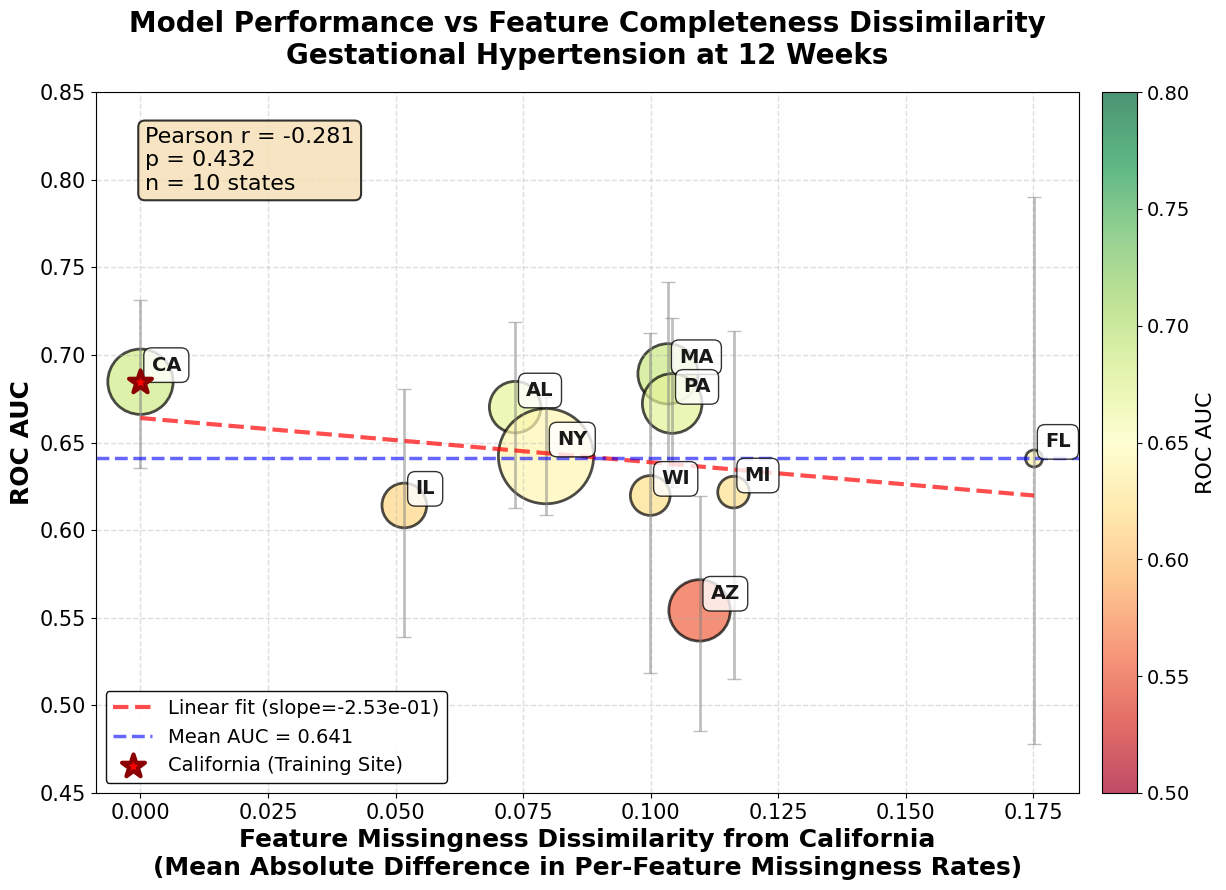

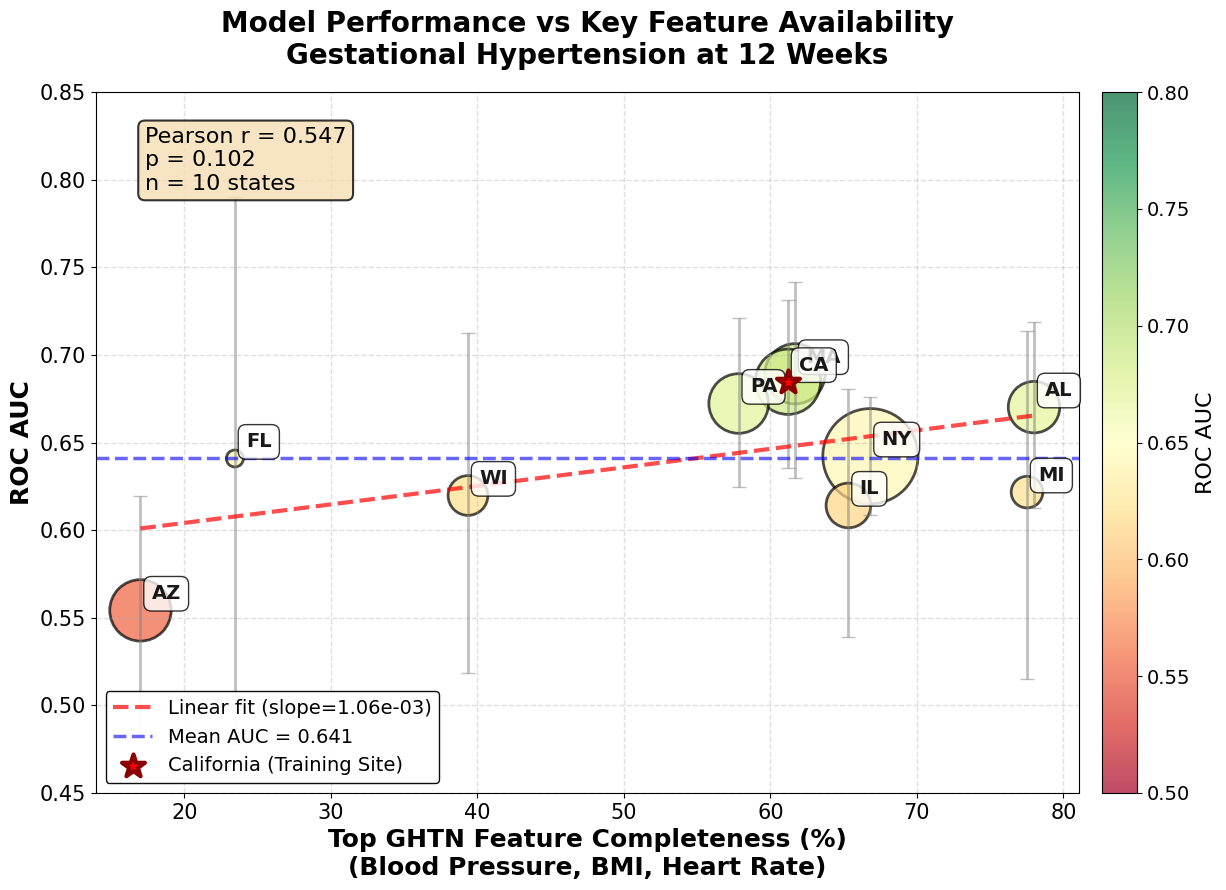

In [38]:
# # --- Plot: Feature Missingness Dissimilarity vs AUC (standalone) ---

# fig_left, ax_left = plt.subplots(figsize=(13, 9))

# x_data = state_results_df['l1_mean_abs_diff']
# y_data = state_results_df['roc_auc']
# sizes = state_results_df['n_total'] * 3
# overall_mean = state_results_df['roc_auc'].mean()

# scatter_left = ax_left.scatter(x_data, y_data, s=sizes, c=y_data, cmap='RdYlGn',
#                                alpha=0.7, edgecolors='black', linewidth=2,
#                                vmin=0.5, vmax=0.8)

# ax_left.errorbar(x_data, y_data,
#                  yerr=[y_data - state_results_df['ci_lower'],
#                        state_results_df['ci_upper'] - y_data],
#                  fmt='none', ecolor='gray', alpha=0.5, capsize=5, linewidth=2)

# for _, row in state_results_df.iterrows():
#     ax_left.annotate(row['state'],
#                      (row['l1_mean_abs_diff'], row['roc_auc']),
#                      xytext=(8, 8), textcoords='offset points',
#                      fontsize=14, fontweight='bold', alpha=0.9,
#                      bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
#                               edgecolor='black', alpha=0.8, linewidth=1))

# valid = state_results_df[['l1_mean_abs_diff', 'roc_auc']].dropna()
# if len(valid) > 2:
#     z = np.polyfit(valid['l1_mean_abs_diff'], valid['roc_auc'], 1)
#     p_fit = np.poly1d(z)
#     x_line = np.linspace(valid['l1_mean_abs_diff'].min(),
#                          valid['l1_mean_abs_diff'].max(), 100)
#     corr, p_val = stats.pearsonr(valid['l1_mean_abs_diff'], valid['roc_auc'])
#     ax_left.plot(x_line, p_fit(x_line), "r--", alpha=0.7, linewidth=3,
#                  label=f'Linear fit (slope={z[0]:.2e})')
#     ax_left.text(0.05, 0.95,
#                  f'Pearson r = {corr:.3f}\np = {p_val:.3f}\nn = {len(valid)} states',
#                  transform=ax_left.transAxes, fontsize=16, verticalalignment='top',
#                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8,
#                           edgecolor='black', linewidth=1.5))

# ax_left.axhline(y=overall_mean, color='blue', linestyle='--', alpha=0.6, linewidth=2.5,
#                 label=f'Mean AUC = {overall_mean:.3f}')

# ca_row = state_results_df[state_results_df['state'] == 'CA'].iloc[0]
# ax_left.scatter(ca_row['l1_mean_abs_diff'], ca_row['roc_auc'],
#                 s=300, c='red', marker='*', edgecolors='darkred', linewidth=3,
#                 zorder=5, label='California (Training Site)')

# ax_left.set_xlabel('Feature Missingness Dissimilarity from California\n'
#                     '(Mean Absolute Difference in Per-Feature Missingness Rates)',
#                     fontsize=18, fontweight='bold')
# ax_left.set_ylabel('ROC AUC', fontsize=18, fontweight='bold')
# ax_left.set_title('Model Performance vs Feature Completeness Dissimilarity\n'
#                    'Gestational Hypertension at 12 Weeks',
#                    fontsize=20, fontweight='bold', pad=20)
# ax_left.legend(fontsize=14, loc='lower left', framealpha=0.95, edgecolor='black', fancybox=True)
# ax_left.grid(True, alpha=0.4, linestyle='--', linewidth=1)
# ax_left.set_ylim([0.45, 0.85])
# ax_left.tick_params(axis='both', labelsize=15)

# cbar_l = plt.colorbar(scatter_left, ax=ax_left, label='ROC AUC', pad=0.02)
# cbar_l.ax.tick_params(labelsize=14)
# cbar_l.set_label('ROC AUC', fontsize=16)

# plt.tight_layout()
# plt.savefig('feature_missingness_dissimilarity.png', dpi=300, bbox_inches='tight')
# plt.show()


# # --- Plot: Top Feature Completeness vs AUC (standalone) ---

# fig_right, ax_right = plt.subplots(figsize=(13, 9))

# x_data_r = state_results_df['top_feat_completeness']

# scatter_right = ax_right.scatter(x_data_r, y_data, s=sizes, c=y_data, cmap='RdYlGn',
#                                  alpha=0.7, edgecolors='black', linewidth=2,
#                                  vmin=0.5, vmax=0.8)

# ax_right.errorbar(x_data_r, y_data,
#                   yerr=[y_data - state_results_df['ci_lower'],
#                         state_results_df['ci_upper'] - y_data],
#                   fmt='none', ecolor='gray', alpha=0.5, capsize=5, linewidth=2)

# for _, row in state_results_df.iterrows():
#     ax_right.annotate(row['state'],
#                       (row['top_feat_completeness'], row['roc_auc']),
#                       xytext=(8, 8), textcoords='offset points',
#                       fontsize=14, fontweight='bold', alpha=0.9,
#                       bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
#                                edgecolor='black', alpha=0.8, linewidth=1))

# valid_r = state_results_df[['top_feat_completeness', 'roc_auc']].dropna()
# if len(valid_r) > 2:
#     z_r = np.polyfit(valid_r['top_feat_completeness'], valid_r['roc_auc'], 1)
#     p_fit_r = np.poly1d(z_r)
#     x_line_r = np.linspace(valid_r['top_feat_completeness'].min(),
#                            valid_r['top_feat_completeness'].max(), 100)
#     corr_r, p_val_r = stats.pearsonr(valid_r['top_feat_completeness'], valid_r['roc_auc'])
#     ax_right.plot(x_line_r, p_fit_r(x_line_r), "r--", alpha=0.7, linewidth=3,
#                   label=f'Linear fit (slope={z_r[0]:.2e})')
#     ax_right.text(0.05, 0.95,
#                   f'Pearson r = {corr_r:.3f}\np = {p_val_r:.3f}\nn = {len(valid_r)} states',
#                   transform=ax_right.transAxes, fontsize=16, verticalalignment='top',
#                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8,
#                            edgecolor='black', linewidth=1.5))

# ax_right.axhline(y=overall_mean, color='blue', linestyle='--', alpha=0.6, linewidth=2.5,
#                  label=f'Mean AUC = {overall_mean:.3f}')

# ca_row = state_results_df[state_results_df['state'] == 'CA'].iloc[0]
# ax_right.scatter(ca_row['top_feat_completeness'], ca_row['roc_auc'],
#                  s=300, c='red', marker='*', edgecolors='darkred', linewidth=3,
#                  zorder=5, label='California (Training Site)')

# ax_right.set_xlabel('Top GHTN Feature Completeness (%)\n'
#                      '(Blood Pressure, BMI, Heart Rate)',
#                      fontsize=18, fontweight='bold')
# ax_right.set_ylabel('ROC AUC', fontsize=18, fontweight='bold')
# ax_right.set_title('Model Performance vs Key Feature Availability\n'
#                     'Gestational Hypertension at 12 Weeks',
#                     fontsize=20, fontweight='bold', pad=20)
# ax_right.legend(fontsize=14, loc='lower left', framealpha=0.95, edgecolor='black', fancybox=True)
# ax_right.grid(True, alpha=0.4, linestyle='--', linewidth=1)
# ax_right.set_ylim([0.45, 0.85])
# ax_right.tick_params(axis='both', labelsize=15)

# cbar_r = plt.colorbar(scatter_right, ax=ax_right, label='ROC AUC', pad=0.02)
# cbar_r.ax.tick_params(labelsize=14)
# cbar_r.set_label('ROC AUC', fontsize=16)

# plt.tight_layout()
# plt.savefig('top_feature_completeness.png', dpi=300, bbox_inches='tight')
# plt.show()

 FEATURE DISTRIBUTION SIMILARITY ANALYSIS

In [39]:

# # ---------------------------------------------------------------
# # Compute Per-State Feature Distribution Profiles
# # ---------------------------------------------------------------

# from scipy.spatial.distance import cosine, euclidean
# from scipy import stats

# print("=" * 70)
# print("FEATURE DISTRIBUTION SIMILARITY ANALYSIS")
# print("=" * 70)

# # Re-use eval_indices and existing_feats from missingness analysis
# # eval_indices = df_eval_full.index
# # existing_feats = [f for f in feats_to_train if f in df.columns]
# # df_raw_features = df.loc[eval_indices, existing_feats].copy()

# # --- Compute per-state summary statistics for observed (non-missing) values ---
# # We use mean and std of observed values per feature per state.
# # These capture the actual distributions that XGBoost sees when values ARE present.

# feature_means_by_state = {}
# feature_medians_by_state = {}
# feature_stds_by_state = {}

# for state in states_analyzed:
#     state_mask = df_eval_full.loc[eval_indices, 'state_clean'] == state
#     state_raw = df_raw_features.loc[state_mask]
#     feature_means_by_state[state] = state_raw.mean()      # NaN ignored by default
#     feature_medians_by_state[state] = state_raw.median()
#     feature_stds_by_state[state] = state_raw.std()

# means_df = pd.DataFrame(feature_means_by_state).T
# medians_df = pd.DataFrame(feature_medians_by_state).T

# print(f"Computed distribution profiles for {len(states_analyzed)} states")
# print(f"Features with at least some observed values: {means_df.notna().any().sum()}")

# # Drop features that are entirely NaN across all states (no signal for comparison)
# # These are features missing everywhere - they can't contribute to distributional differences
# valid_features = means_df.columns[means_df.notna().any()]
# means_df_clean = means_df[valid_features]
# medians_df_clean = medians_df[valid_features]

# print(f"Features retained for distributional comparison: {len(valid_features)}")



FEATURE DISTRIBUTION SIMILARITY ANALYSIS
Computed distribution profiles for 10 states
Features with at least some observed values: 148
Features retained for distributional comparison: 148


In [40]:
# # ---------------------------------------------------------------
# #  Compute Distributional Distance from California
# # ---------------------------------------------------------------

# print("\n" + "=" * 70)
# print("DISTRIBUTIONAL DISTANCE FROM CALIFORNIA")
# print("=" * 70)

# ca_means = means_df_clean.loc['CA']

# # Global standard deviation across all states (for standardization)
# # This puts all features on the same scale before computing distances
# global_std = means_df_clean.std(axis=0)

# # Standardized mean difference (SMD): classic covariate shift metric
# # For each feature: |state_mean - CA_mean| / global_std
# # Then average across features
# # This is essentially an average absolute standardized mean difference (ASMD)

# distribution_distances = {}

# for state in states_analyzed:
#     state_means = means_df_clean.loc[state]

#     # Only compare features where both state and CA have observed values
#     both_observed = state_means.notna() & ca_means.notna() & (global_std > 0)
#     n_comparable = both_observed.sum()

#     if n_comparable == 0:
#         distribution_distances[state] = {
#             'smd_l1': np.nan,
#             'smd_l2': np.nan,
#             'raw_l1': np.nan,
#             'n_features_compared': 0,
#         }
#         continue

#     s_means = state_means[both_observed]
#     c_means = ca_means[both_observed]
#     g_std = global_std[both_observed]

#     # Standardized differences
#     standardized_diffs = (s_means - c_means) / g_std

#     # 1. Average absolute SMD (L1 in standardized space)
#     smd_l1 = standardized_diffs.abs().mean()

#     # 2. Euclidean distance in standardized space (L2)
#     smd_l2 = np.sqrt((standardized_diffs ** 2).sum())

#     # 3. Raw (unstandardized) mean absolute difference
#     raw_l1 = (s_means - c_means).abs().mean()

#     # 4. Find the feature with the largest standardized shift
#     worst_idx = standardized_diffs.abs().idxmax()
#     worst_smd = standardized_diffs.abs().max()

#     distribution_distances[state] = {
#         'smd_l1': smd_l1,
#         'smd_l2': smd_l2,
#         'raw_l1': raw_l1,
#         'n_features_compared': int(n_comparable),
#         'worst_shifted_feature': worst_idx,
#         'worst_smd': worst_smd,
#     }

# dist_dist_df = pd.DataFrame(distribution_distances).T
# dist_dist_df.index.name = 'state'

# print("\nDistributional Distance from California:")
# print(f"{'State':<6} {'Avg |SMD|':>10} {'L2 SMD':>10} {'# Features':>12} {'Worst Feature':>25} {'Worst SMD':>10}")
# for state in states_analyzed:
#     row = dist_dist_df.loc[state]
#     worst_feat = row.get('worst_shifted_feature', 'N/A')
#     print(f"  {state:<4} {row['smd_l1']:>10.3f} {row['smd_l2']:>10.3f} {row['n_features_compared']:>10.0f}"
#           f"   {str(worst_feat):>25s} {row.get('worst_smd', np.nan):>10.3f}")




DISTRIBUTIONAL DISTANCE FROM CALIFORNIA

Distributional Distance from California:
State   Avg |SMD|     L2 SMD   # Features             Worst Feature  Worst SMD
  MA        0.937     15.140        147                  pp_HGB_std      3.258
  CA        0.000      0.000        147                  pp_ALT_avg      0.000
  PA        0.757     12.007        147           pp_CREATININE_avg      2.764
  AL        1.126     17.379        147                  pp_WBC_std      3.176
  NY        0.685     11.202        147              pp_GLU_RAN_min      3.015
  FL        1.413     20.855        147                pain_chronic      3.288
  MI        0.787     12.286        143              pain_rightquad      2.789
  WI        0.895     14.208        147              resp_infection      2.859
  IL        0.783     13.250        147                  pp_RBC_std      3.369
  AZ        1.106     16.743        147              pp_CALCIUM_std      3.036


In [41]:
# ---------------------------------------------------------------
# Merge with State Results and Correlate
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("CORRELATION: DISTRIBUTIONAL SIMILARITY vs MODEL PERFORMANCE")
print("=" * 70)

# Merge into state_results_df
state_results_df = state_results_df.set_index('state')
for col in ['smd_l1', 'smd_l2', 'raw_l1']:
    state_results_df[col] = pd.to_numeric(dist_dist_df[col], errors='coerce')
state_results_df = state_results_df.reset_index()

# Compute correlations for all metrics (old + new)
all_metrics = {
    'smd_l1': 'Avg Standardized Mean Difference (Distribution)',
    'smd_l2': 'Euclidean SMD (Distribution)',
    'l1_mean_abs_diff': 'Mean Abs Missingness Difference',
    'cosine_distance': 'Cosine Distance (Missingness)',
    'top_feat_completeness': 'Top GHTN Feature Completeness',
    'overall_completeness': 'Overall Feature Completeness (%)',
    'demo_similarity_score': 'Demographic Dissimilarity',
    'distance_from_ca': 'Geographic Distance',
}

print(f"\n{'Metric':<50} {'r':>7} {'p':>9} {'|r|':>7}")
print("-" * 75)

all_correlation_results = {}
for metric, label in all_metrics.items():
    if metric not in state_results_df.columns:
        continue
    valid = state_results_df[[metric, 'roc_auc']].dropna()
    if len(valid) > 2:
        corr, p_val = stats.pearsonr(valid[metric], valid['roc_auc'])
        all_correlation_results[metric] = {'label': label, 'r': corr, 'p': p_val}
        sig = "***" if p_val < 0.01 else "**" if p_val < 0.05 else "*" if p_val < 0.1 else ""
        print(f"  {label:<48} {corr:>7.3f} {p_val:>9.3f} {abs(corr):>7.3f} {sig}")

print("\n(*** p<0.01, ** p<0.05, * p<0.1)")



CORRELATION: DISTRIBUTIONAL SIMILARITY vs MODEL PERFORMANCE

Metric                                                   r         p     |r|
---------------------------------------------------------------------------
  Avg Standardized Mean Difference (Distribution)   -0.352     0.318   0.352 
  Euclidean SMD (Distribution)                      -0.351     0.320   0.351 
  Mean Abs Missingness Difference                   -0.281     0.432   0.281 
  Cosine Distance (Missingness)                     -0.271     0.449   0.271 
  Top GHTN Feature Completeness                      0.547     0.102   0.547 
  Overall Feature Completeness (%)                   0.431     0.214   0.431 
  Demographic Dissimilarity                         -0.002     0.995   0.002 
  Geographic Distance                                0.303     0.395   0.303 

(*** p<0.01, ** p<0.05, * p<0.1)


In [42]:
# # ---------------------------------------------------------------
# #  Top-Feature Distribution Shift
# # ---------------------------------------------------------------

# print("\n" + "=" * 70)
# print("TOP GHTN FEATURE DISTRIBUTION SHIFT BY STATE")
# print("=" * 70)

# # Same top features as before
# top_ghtn_features = ['ep_sbp_avg', 'pp_sbp_avg', 'ep_dbp_avg', 'pp_dbp_avg',
#                      'PPREG_BMI', 'ep_sbp_max', 'pp_sbp_max', 'ep_dbp_max',
#                      'pp_dbp_max', 'ep_hr_avg', 'pp_hr_avg']
# top_ghtn_available = [f for f in top_ghtn_features if f in df_raw_features.columns]

# # Compute mean of top features per state and compare to CA
# ca_top_means = df_raw_features.loc[
#     df_eval_full.loc[eval_indices, 'state_clean'] == 'CA', top_ghtn_available
# ].mean()

# ca_top_stds = df_raw_features.loc[
#     df_eval_full.loc[eval_indices, 'state_clean'] == 'CA', top_ghtn_available
# ].std()

# top_feat_dist_shift = {}
# for state in states_analyzed:
#     state_mask = df_eval_full.loc[eval_indices, 'state_clean'] == state
#     state_top_means = df_raw_features.loc[state_mask, top_ghtn_available].mean()

#     # SMD using CA's std as reference (since CA is the training set)
#     both_valid = state_top_means.notna() & ca_top_means.notna() & (ca_top_stds > 0)
#     if both_valid.sum() > 0:
#         smds = ((state_top_means[both_valid] - ca_top_means[both_valid]) /
#                 ca_top_stds[both_valid])
#         top_feat_dist_shift[state] = {
#             'top_feat_avg_abs_smd': smds.abs().mean(),
#             'top_feat_max_smd': smds.abs().max(),
#             'top_feat_max_smd_feature': smds.abs().idxmax(),
#         }
#     else:
#         top_feat_dist_shift[state] = {
#             'top_feat_avg_abs_smd': np.nan,
#             'top_feat_max_smd': np.nan,
#             'top_feat_max_smd_feature': 'N/A',
#         }

# top_dist_df = pd.DataFrame(top_feat_dist_shift).T

# print("\nTop Feature Distribution Shift (SMD from CA):")
# for state in states_analyzed:
#     row = top_dist_df.loc[state]
#     print(f"  {state:<4}: avg |SMD| = {row['top_feat_avg_abs_smd']:.3f}, "
#           f"max |SMD| = {row['top_feat_max_smd']:.3f} ({row['top_feat_max_smd_feature']})")

# # Add to state results and correlate
# state_results_df = state_results_df.set_index('state')
# state_results_df['top_feat_smd'] = pd.to_numeric(top_dist_df['top_feat_avg_abs_smd'],
#                                                    errors='coerce')
# state_results_df = state_results_df.reset_index()

# valid = state_results_df[['top_feat_smd', 'roc_auc']].dropna()
# if len(valid) > 2:
#     corr, p_val = stats.pearsonr(valid['top_feat_smd'], valid['roc_auc'])
#     print(f"\nTop Feature Distribution Shift vs AUC: r = {corr:.3f}, p = {p_val:.3f}")
#     all_correlation_results['top_feat_smd'] = {
#         'label': 'Top GHTN Feature Distribution Shift', 'r': corr, 'p': p_val
#     }



TOP GHTN FEATURE DISTRIBUTION SHIFT BY STATE

Top Feature Distribution Shift (SMD from CA):
  MA  : avg |SMD| = 0.162, max |SMD| = 0.354 (pp_sbp_max)
  CA  : avg |SMD| = 0.000, max |SMD| = 0.000 (ep_sbp_avg)
  PA  : avg |SMD| = 0.200, max |SMD| = 0.420 (pp_sbp_max)
  AL  : avg |SMD| = 0.531, max |SMD| = 0.711 (pp_dbp_max)
  NY  : avg |SMD| = 0.190, max |SMD| = 0.301 (ep_dbp_max)
  FL  : avg |SMD| = 0.945, max |SMD| = 2.080 (ep_sbp_avg)
  MI  : avg |SMD| = 0.105, max |SMD| = 0.186 (pp_dbp_avg)
  WI  : avg |SMD| = 0.123, max |SMD| = 0.275 (pp_sbp_max)
  IL  : avg |SMD| = 0.149, max |SMD| = 0.309 (pp_dbp_max)
  AZ  : avg |SMD| = 0.408, max |SMD| = 0.875 (ep_dbp_avg)

Top Feature Distribution Shift vs AUC: r = -0.137, p = 0.705


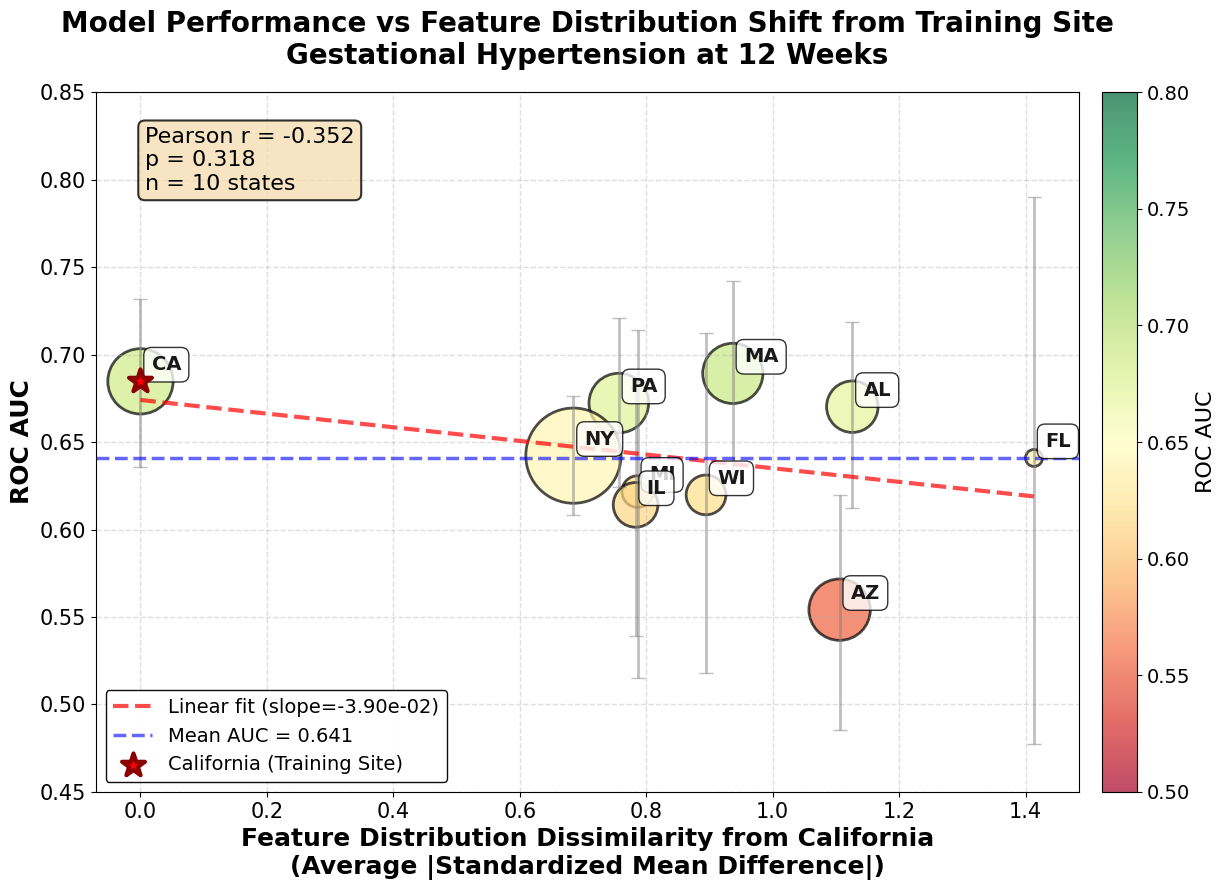

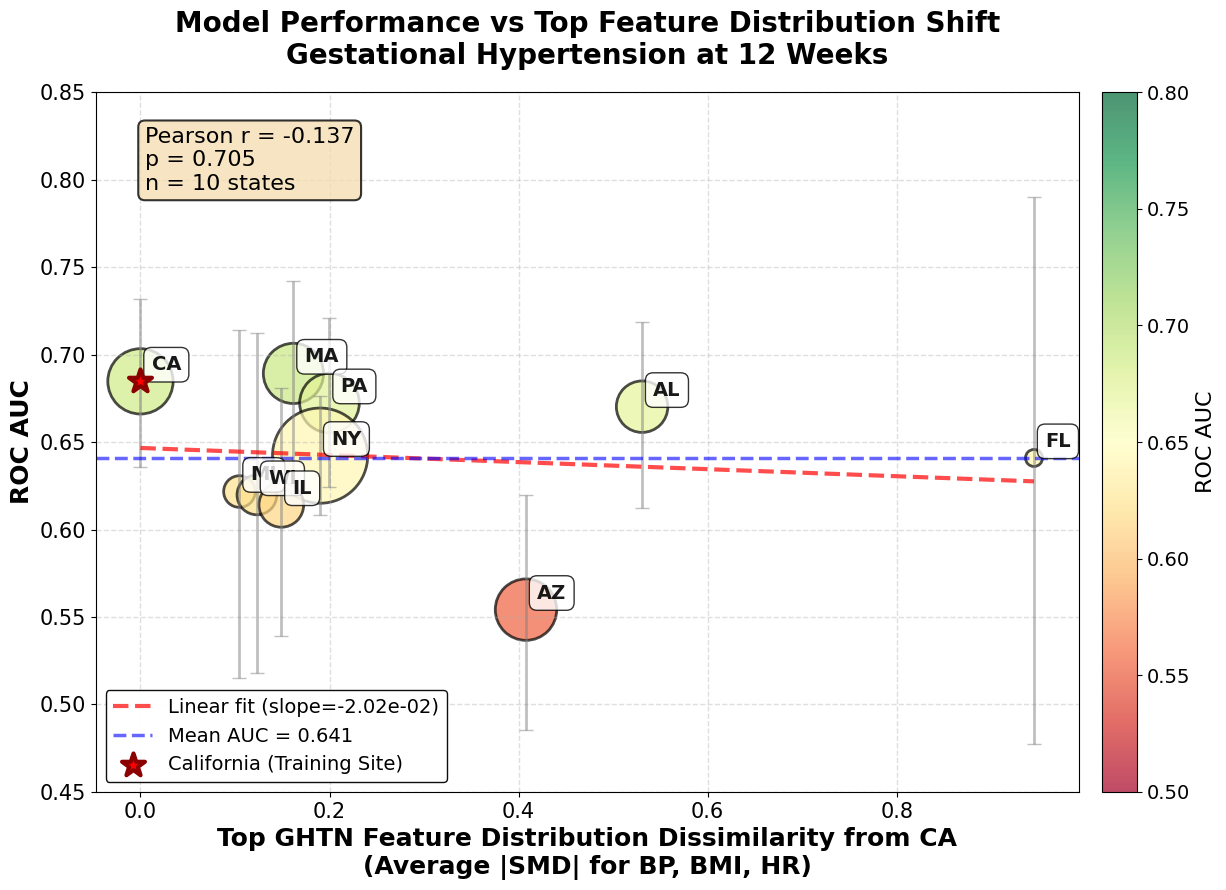

In [43]:
# # --- Plot A: All-Feature Distribution Shift (standalone) ---

# fig_a, ax_a = plt.subplots(figsize=(13, 9))

# x_data = pd.to_numeric(state_results_df['smd_l1'], errors='coerce')
# y_data = state_results_df['roc_auc']
# sizes = state_results_df['n_total'] * 3
# overall_mean = state_results_df['roc_auc'].mean()
# valid_mask = x_data.notna() & y_data.notna()

# scatter_a = ax_a.scatter(x_data[valid_mask], y_data[valid_mask],
#                          s=sizes[valid_mask], c=y_data[valid_mask], cmap='RdYlGn',
#                          alpha=0.7, edgecolors='black', linewidth=2, vmin=0.5, vmax=0.8)

# ax_a.errorbar(x_data[valid_mask], y_data[valid_mask],
#               yerr=[y_data[valid_mask] - state_results_df.loc[valid_mask, 'ci_lower'],
#                     state_results_df.loc[valid_mask, 'ci_upper'] - y_data[valid_mask]],
#               fmt='none', ecolor='gray', alpha=0.5, capsize=5, linewidth=2)

# for _, row in state_results_df[valid_mask].iterrows():
#     ax_a.annotate(row['state'], (float(row['smd_l1']), row['roc_auc']),
#                   xytext=(8, 8), textcoords='offset points',
#                   fontsize=14, fontweight='bold', alpha=0.9,
#                   bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
#                            edgecolor='black', alpha=0.8, linewidth=1))

# valid = state_results_df[['smd_l1', 'roc_auc']].dropna()
# valid['smd_l1'] = pd.to_numeric(valid['smd_l1'], errors='coerce')
# valid = valid.dropna()
# if len(valid) > 2:
#     z = np.polyfit(valid['smd_l1'], valid['roc_auc'], 1)
#     p = np.poly1d(z)
#     x_line = np.linspace(valid['smd_l1'].min(), valid['smd_l1'].max(), 100)
#     ax_a.plot(x_line, p(x_line), "r--", alpha=0.7, linewidth=3,
#               label=f'Linear fit (slope={z[0]:.2e})')
#     corr, p_val = stats.pearsonr(valid['smd_l1'], valid['roc_auc'])
#     ax_a.text(0.05, 0.95,
#               f'Pearson r = {corr:.3f}\np = {p_val:.3f}\nn = {len(valid)} states',
#               transform=ax_a.transAxes, fontsize=16, verticalalignment='top',
#               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8,
#                        edgecolor='black', linewidth=1.5))

# ax_a.axhline(y=overall_mean, color='blue', linestyle='--', alpha=0.6, linewidth=2.5,
#              label=f'Mean AUC = {overall_mean:.3f}')

# ca_row = state_results_df[state_results_df['state'] == 'CA']
# if len(ca_row) > 0:
#     ax_a.scatter(float(ca_row['smd_l1'].iloc[0]), ca_row['roc_auc'].iloc[0],
#                  s=300, c='red', marker='*', edgecolors='darkred',
#                  linewidth=3, zorder=5, label='California (Training Site)')

# ax_a.set_xlabel('Feature Distribution Dissimilarity from California\n'
#                 '(Average |Standardized Mean Difference|)', fontsize=18, fontweight='bold')
# ax_a.set_ylabel('ROC AUC', fontsize=18, fontweight='bold')
# ax_a.set_title('Model Performance vs Feature Distribution Shift from Training Site\n'
#                'Gestational Hypertension at 12 Weeks', fontsize=20, fontweight='bold', pad=20)
# ax_a.legend(fontsize=14, loc='lower left', framealpha=0.95, edgecolor='black', fancybox=True)
# ax_a.grid(True, alpha=0.4, linestyle='--', linewidth=1)
# ax_a.set_ylim([0.45, 0.85])
# ax_a.tick_params(axis='both', labelsize=15)

# cbar_a = plt.colorbar(scatter_a, ax=ax_a, label='ROC AUC', pad=0.02)
# cbar_a.ax.tick_params(labelsize=14)
# cbar_a.set_label('ROC AUC', fontsize=16)

# plt.tight_layout()
# plt.savefig('distribution_shift_all_features.png', dpi=300, bbox_inches='tight')
# plt.show()


# # --- Plot B: Top GHTN Feature Distribution Shift (standalone) ---

# fig_b, ax_b = plt.subplots(figsize=(13, 9))

# x_data_b = pd.to_numeric(state_results_df['top_feat_smd'], errors='coerce')
# valid_mask_b = x_data_b.notna() & y_data.notna()

# scatter_b = ax_b.scatter(x_data_b[valid_mask_b], y_data[valid_mask_b],
#                          s=sizes[valid_mask_b], c=y_data[valid_mask_b], cmap='RdYlGn',
#                          alpha=0.7, edgecolors='black', linewidth=2, vmin=0.5, vmax=0.8)

# ax_b.errorbar(x_data_b[valid_mask_b], y_data[valid_mask_b],
#               yerr=[y_data[valid_mask_b] - state_results_df.loc[valid_mask_b, 'ci_lower'],
#                     state_results_df.loc[valid_mask_b, 'ci_upper'] - y_data[valid_mask_b]],
#               fmt='none', ecolor='gray', alpha=0.5, capsize=5, linewidth=2)

# for _, row in state_results_df[valid_mask_b].iterrows():
#     ax_b.annotate(row['state'], (float(row['top_feat_smd']), row['roc_auc']),
#                   xytext=(8, 8), textcoords='offset points',
#                   fontsize=14, fontweight='bold', alpha=0.9,
#                   bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
#                            edgecolor='black', alpha=0.8, linewidth=1))

# valid_b = state_results_df[['top_feat_smd', 'roc_auc']].dropna()
# valid_b['top_feat_smd'] = pd.to_numeric(valid_b['top_feat_smd'], errors='coerce')
# valid_b = valid_b.dropna()
# if len(valid_b) > 2:
#     z_b = np.polyfit(valid_b['top_feat_smd'], valid_b['roc_auc'], 1)
#     p_b = np.poly1d(z_b)
#     x_line_b = np.linspace(valid_b['top_feat_smd'].min(), valid_b['top_feat_smd'].max(), 100)
#     ax_b.plot(x_line_b, p_b(x_line_b), "r--", alpha=0.7, linewidth=3,
#               label=f'Linear fit (slope={z_b[0]:.2e})')
#     corr_b, p_val_b = stats.pearsonr(valid_b['top_feat_smd'], valid_b['roc_auc'])
#     ax_b.text(0.05, 0.95,
#               f'Pearson r = {corr_b:.3f}\np = {p_val_b:.3f}\nn = {len(valid_b)} states',
#               transform=ax_b.transAxes, fontsize=16, verticalalignment='top',
#               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8,
#                        edgecolor='black', linewidth=1.5))

# ax_b.axhline(y=overall_mean, color='blue', linestyle='--', alpha=0.6, linewidth=2.5,
#              label=f'Mean AUC = {overall_mean:.3f}')

# if len(ca_row) > 0:
#     ax_b.scatter(float(ca_row['top_feat_smd'].iloc[0]), ca_row['roc_auc'].iloc[0],
#                  s=300, c='red', marker='*', edgecolors='darkred',
#                  linewidth=3, zorder=5, label='California (Training Site)')

# ax_b.set_xlabel('Top GHTN Feature Distribution Dissimilarity from CA\n'
#                 '(Average |SMD| for BP, BMI, HR)', fontsize=18, fontweight='bold')
# ax_b.set_ylabel('ROC AUC', fontsize=18, fontweight='bold')
# ax_b.set_title('Model Performance vs Top Feature Distribution Shift\n'
#                'Gestational Hypertension at 12 Weeks', fontsize=20, fontweight='bold', pad=20)
# ax_b.legend(fontsize=14, loc='lower left', framealpha=0.95, edgecolor='black', fancybox=True)
# ax_b.grid(True, alpha=0.4, linestyle='--', linewidth=1)
# ax_b.set_ylim([0.45, 0.85])
# ax_b.tick_params(axis='both', labelsize=15)

# cbar_b = plt.colorbar(scatter_b, ax=ax_b, label='ROC AUC', pad=0.02)
# cbar_b.ax.tick_params(labelsize=14)
# cbar_b.set_label('ROC AUC', fontsize=16)

# plt.tight_layout()
# plt.savefig('distribution_shift_top_features.png', dpi=300, bbox_inches='tight')
# plt.show()

In [44]:
# # ---------------------------------------------------------------
# #  Summary Table and Export
# # ---------------------------------------------------------------

# print("\n" + "=" * 70)
# print("FINAL SUMMARY: ALL SIMILARITY METRICS vs MODEL PERFORMANCE")
# print("=" * 70)

# print(f"\n{'Metric':<50} {'r':>7} {'p':>9} {'|r|':>7} {'Sig':>5}")
# print("-" * 80)
# for metric, info in sorted(all_correlation_results.items(),
#                             key=lambda x: abs(x[1]['r']), reverse=True):
#     sig = "***" if info['p'] < 0.01 else "**" if info['p'] < 0.05 else \
#           "*" if info['p'] < 0.1 else ""
#     print(f"  {info['label']:<48} {info['r']:>7.3f} {info['p']:>9.3f} "
#           f"{abs(info['r']):>7.3f} {sig:>5}")

# print("\nInterpretation:")
# # Find strongest metric
# strongest = max(all_correlation_results.items(), key=lambda x: abs(x[1]['r']))
# print(f"  Strongest predictor of cross-site performance: {strongest[1]['label']}")
# print(f"    r = {strongest[1]['r']:.3f}, p = {strongest[1]['p']:.3f}")

# # Export updated results
# export_cols = ['state', 'n_total', 'n_positive', 'prevalence', 'roc_auc',
#                'ci_lower', 'ci_upper', 'distance_from_ca', 'demo_similarity_score',
#                'l1_mean_abs_diff', 'cosine_distance', 'overall_completeness',
#                'top_feat_completeness', 'smd_l1', 'smd_l2', 'top_feat_smd']

# export_final = state_results_df[[c for c in export_cols
#                                   if c in state_results_df.columns]].copy()
# export_final = export_final.round(3)

# output_file = f'per_state_results_full_similarity_{outcome.replace(" ", "_")}.csv'
# export_final.to_csv(output_file, index=False)
# print(f"\nFull results exported to: {output_file}")


FINAL SUMMARY: ALL SIMILARITY METRICS vs MODEL PERFORMANCE

Metric                                                   r         p     |r|   Sig
--------------------------------------------------------------------------------
  Top GHTN Feature Completeness                      0.547     0.102   0.547      
  Overall Feature Completeness (%)                   0.431     0.214   0.431      
  Avg Standardized Mean Difference (Distribution)   -0.352     0.318   0.352      
  Euclidean SMD (Distribution)                      -0.351     0.320   0.351      
  Geographic Distance                                0.303     0.395   0.303      
  Mean Abs Missingness Difference                   -0.281     0.432   0.281      
  Cosine Distance (Missingness)                     -0.271     0.449   0.271      
  Top GHTN Feature Distribution Shift               -0.137     0.705   0.137      
  Demographic Dissimilarity                         -0.002     0.995   0.002      

Interpretation:
  Strongest

## Export Results

In [45]:
# # Round numerical columns for export
# export_df = state_results_df.copy()
# numeric_cols = export_df.select_dtypes(include=[np.number]).columns
# export_df[numeric_cols] = export_df[numeric_cols].round(3)

# # Export to CSV
# output_file = 'per_state_results_PE_12w.csv'
# export_df.to_csv(output_file, index=False)

# print(f"\n Results exported to: {output_file}")
# print(f"  Total states analyzed: {len(export_df)}")
# print(f"  Columns exported: {len(export_df.columns)}")

# print("="*70)
# print("RESULTS")
# print("="*70)
# display_cols = ['state', 'n_total', 'n_positive', 'roc_auc', 'ci_lower', 'ci_upper', 
#                 'distance_from_ca', 'demo_similarity_score']
# print(export_df[display_cols].to_string(index=False))


 Results exported to: per_state_results_PE_12w.csv
  Total states analyzed: 10
  Columns exported: 34
RESULTS
state  n_total  n_positive  roc_auc  ci_lower  ci_upper  distance_from_ca  demo_similarity_score
   MA      627         115    0.689     0.630     0.742          2577.009                 15.853
   CA      737         180    0.685     0.636     0.732             0.000                  0.000
   PA      614         164    0.672     0.624     0.721          2297.883                 30.134
   AL      458         148    0.670     0.613     0.719          1877.313                 34.555
   NY     1566         373    0.642     0.609     0.676          2403.656                 13.085
   FL       50          23    0.641     0.478     0.790          2284.023                 29.550
   MI      173          46    0.622     0.515     0.714          1916.253                 28.469
   WI      273          45    0.620     0.518     0.712          1671.412                 32.172
   IL      345  

# The below cells are used to generate the figures

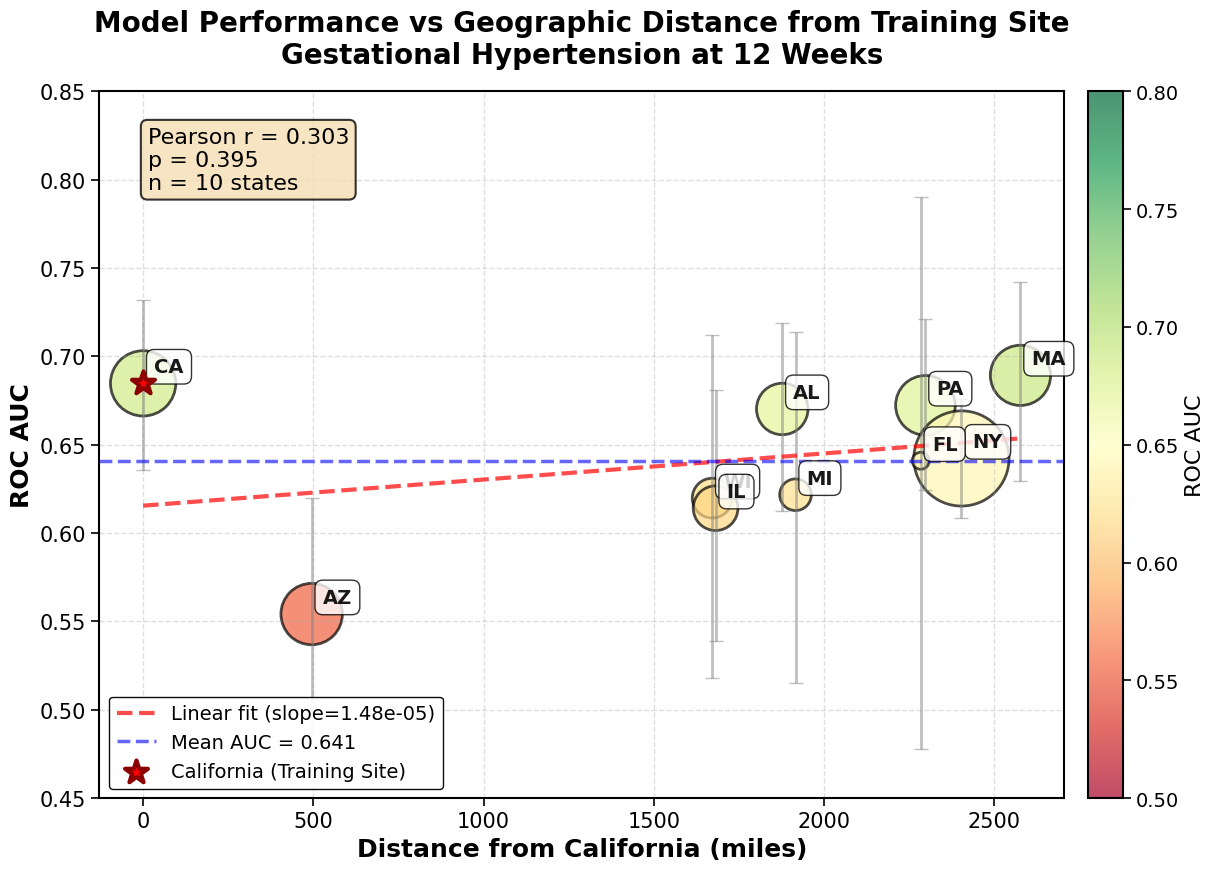

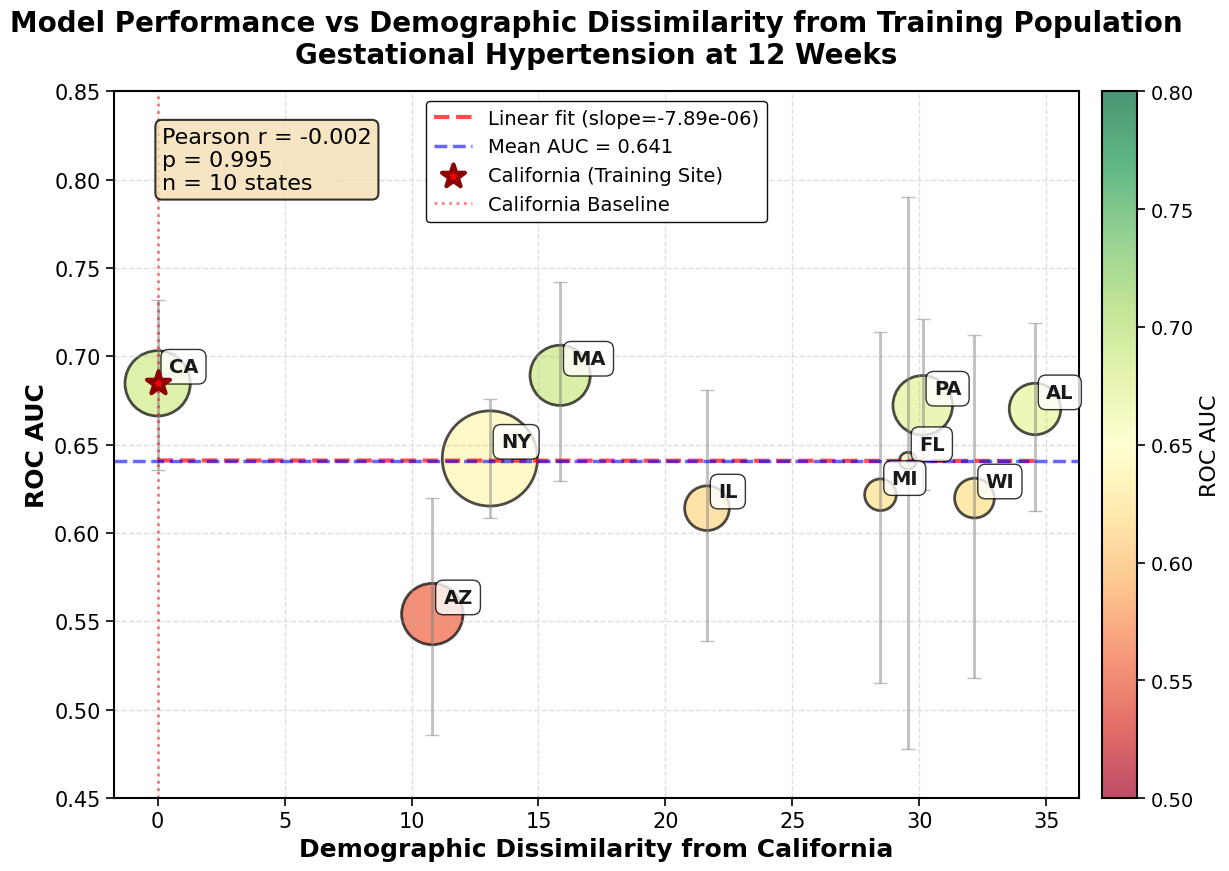

In [46]:
# import matplotlib
# matplotlib.rcParams.update({
#     'font.family': 'sans-serif',
#     'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
#     'font.size': 16,
#     'axes.labelsize': 18,
#     'axes.titlesize': 20,
#     'xtick.labelsize': 15,
#     'ytick.labelsize': 15,
#     'legend.fontsize': 14,
#     'figure.titlesize': 22,
#     'axes.linewidth': 1.5,
#     'xtick.major.width': 1.2,
#     'ytick.major.width': 1.2,
#     'xtick.major.size': 6,
#     'ytick.major.size': 6,
# })

# ## Geographic Distance vs AUC

# fig_geo, ax_geo = plt.subplots(figsize=(13, 9))

# scatter_geo = ax_geo.scatter(state_results_df['distance_from_ca'], 
#                              state_results_df['roc_auc'],
#                              s=state_results_df['n_total']*3,
#                              c=state_results_df['roc_auc'],
#                              cmap='RdYlGn',
#                              alpha=0.7,
#                              edgecolors='black',
#                              linewidth=2,
#                              vmin=0.5, vmax=0.8)

# ax_geo.errorbar(state_results_df['distance_from_ca'], 
#                 state_results_df['roc_auc'],
#                 yerr=[state_results_df['roc_auc'] - state_results_df['ci_lower'],
#                       state_results_df['ci_upper'] - state_results_df['roc_auc']],
#                 fmt='none', ecolor='gray', alpha=0.5, capsize=5, linewidth=2)

# for _, row in state_results_df.iterrows():
#     ax_geo.annotate(row['state'], 
#                     (row['distance_from_ca'], row['roc_auc']),
#                     xytext=(8, 8), textcoords='offset points',
#                     fontsize=14, fontweight='bold', alpha=0.9,
#                     bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
#                              edgecolor='black', alpha=0.8, linewidth=1))

# valid_mask = ~state_results_df['distance_from_ca'].isna()
# x_vals = state_results_df.loc[valid_mask, 'distance_from_ca']
# y_vals = state_results_df.loc[valid_mask, 'roc_auc']

# if len(x_vals) > 2:
#     z = np.polyfit(x_vals, y_vals, 1)
#     p = np.poly1d(z)
#     x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
#     ax_geo.plot(x_line, p(x_line), "r--", alpha=0.7, linewidth=3,
#                 label=f'Linear fit (slope={z[0]:.2e})')
    
#     corr, p_value = stats.pearsonr(x_vals, y_vals)
    
#     textstr = f'Pearson r = {corr:.3f}\np = {p_value:.3f}\nn = {len(x_vals)} states'
#     ax_geo.text(0.05, 0.95, textstr,
#                 transform=ax_geo.transAxes, fontsize=16, verticalalignment='top',
#                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8, 
#                          edgecolor='black', linewidth=1.5))

# overall_auc_mean = state_results_df['roc_auc'].mean()
# ax_geo.axhline(y=overall_auc_mean, color='blue', linestyle='--', alpha=0.6, linewidth=2.5,
#                label=f'Mean AUC = {overall_auc_mean:.3f}')

# ca_data = state_results_df[state_results_df['state'] == 'CA']
# if len(ca_data) > 0:
#     ax_geo.scatter(ca_data['distance_from_ca'], ca_data['roc_auc'],
#                   s=300, marker='*', c='red', edgecolors='darkred', 
#                   linewidth=3, zorder=5, label='California (Training Site)')

# ax_geo.set_xlabel('Distance from California (miles)', fontsize=18, fontweight='bold')
# ax_geo.set_ylabel('ROC AUC', fontsize=18, fontweight='bold')
# ax_geo.set_title('Model Performance vs Geographic Distance from Training Site\nGestational Hypertension at 12 Weeks', 
#                  fontsize=20, fontweight='bold', pad=20)
# ax_geo.legend(fontsize=14, loc='lower left', framealpha=0.95, edgecolor='black', fancybox=True)
# ax_geo.grid(True, alpha=0.4, linestyle='--', linewidth=1)
# ax_geo.set_ylim([0.45, 0.85])

# cbar_geo = plt.colorbar(scatter_geo, ax=ax_geo, label='ROC AUC', pad=0.02)
# cbar_geo.ax.tick_params(labelsize=14)
# cbar_geo.set_label('ROC AUC', fontsize=16)

# plt.tight_layout()
# figure_geo_filename = 'geographic_distance_analysis.png'
# plt.savefig(figure_geo_filename, dpi=300, bbox_inches='tight')
# plt.show()


# ##  Demographic Similarity vs AUC

# if ca_demographics is not None:
#     fig_demo, ax_demo = plt.subplots(figsize=(13, 9))
    
#     scatter_demo = ax_demo.scatter(state_results_df['demo_similarity_score'], 
#                                    state_results_df['roc_auc'],
#                                    s=state_results_df['n_total']*3,
#                                    c=state_results_df['roc_auc'],
#                                    cmap='RdYlGn',
#                                    alpha=0.7,
#                                    edgecolors='black',
#                                    linewidth=2,
#                                    vmin=0.5, vmax=0.8)
    
#     ax_demo.errorbar(state_results_df['demo_similarity_score'], 
#                      state_results_df['roc_auc'],
#                      yerr=[state_results_df['roc_auc'] - state_results_df['ci_lower'],
#                            state_results_df['ci_upper'] - state_results_df['roc_auc']],
#                      fmt='none', ecolor='gray', alpha=0.5, capsize=5, linewidth=2)
    
#     for _, row in state_results_df.iterrows():
#         ax_demo.annotate(row['state'], 
#                         (row['demo_similarity_score'], row['roc_auc']),
#                         xytext=(8, 8), textcoords='offset points',
#                         fontsize=14, fontweight='bold', alpha=0.9,
#                         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
#                                  edgecolor='black', alpha=0.8, linewidth=1))
    
#     valid_data = state_results_df[['demo_similarity_score', 'roc_auc']].dropna()
#     if len(valid_data) > 2:
#         z = np.polyfit(valid_data['demo_similarity_score'], valid_data['roc_auc'], 1)
#         p = np.poly1d(z)
#         x_line = np.linspace(valid_data['demo_similarity_score'].min(), 
#                            valid_data['demo_similarity_score'].max(), 100)
#         corr_demo, p_val_demo = stats.pearsonr(valid_data['demo_similarity_score'], 
#                                                 valid_data['roc_auc'])
#         ax_demo.plot(x_line, p(x_line), "r--", alpha=0.7, linewidth=3,
#                     label=f'Linear fit (slope={z[0]:.2e})')
        
#         textstr = f'Pearson r = {corr_demo:.3f}\np = {p_val_demo:.3f}\nn = {len(valid_data)} states'
#         ax_demo.text(0.05, 0.95, textstr, transform=ax_demo.transAxes,
#                     fontsize=16, verticalalignment='top',
#                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8,
#                              edgecolor='black', linewidth=1.5))
    
#     ax_demo.axhline(y=overall_auc_mean, color='blue', linestyle='--', alpha=0.6, 
#                    linewidth=2.5, label=f'Mean AUC = {overall_auc_mean:.3f}')
    
#     ca_data = state_results_df[state_results_df['state'] == 'CA']
#     if len(ca_data) > 0:
#         ax_demo.scatter(ca_data['demo_similarity_score'], ca_data['roc_auc'],
#                        s=300, marker='*', c='red', edgecolors='darkred', 
#                        linewidth=3, zorder=5, label='California (Training Site)')
    
#     ax_demo.axvline(x=0, color='red', linestyle=':', alpha=0.5, linewidth=2,
#                    label='California Baseline')
    
#     ax_demo.set_xlabel('Demographic Dissimilarity from California', 
#                       fontsize=18, fontweight='bold')
#     ax_demo.set_ylabel('ROC AUC', fontsize=18, fontweight='bold')
#     ax_demo.set_title('Model Performance vs Demographic Dissimilarity from Training Population\nGestational Hypertension at 12 Weeks', 
#                      fontsize=20, fontweight='bold', pad=20)
#     ax_demo.legend(fontsize=14, loc='best', framealpha=0.95, edgecolor='black', fancybox=True)
#     ax_demo.grid(True, alpha=0.4, linestyle='--', linewidth=1)
#     ax_demo.set_ylim([0.45, 0.85])
    
#     cbar_demo = plt.colorbar(scatter_demo, ax=ax_demo, label='ROC AUC', pad=0.02)
#     cbar_demo.ax.tick_params(labelsize=14)
#     cbar_demo.set_label('ROC AUC', fontsize=16)
    
#     plt.tight_layout()
#     figure_demo_filename = 'demographic_similarity_analysis.png'
#     plt.savefig(figure_demo_filename, dpi=300, bbox_inches='tight')
#     plt.show()


CREATING STATE PERFORMANCE BAR CHART WITH CONFIDENCE INTERVALS

✓ Figure saved as: state_performance_bars_with_CI.png


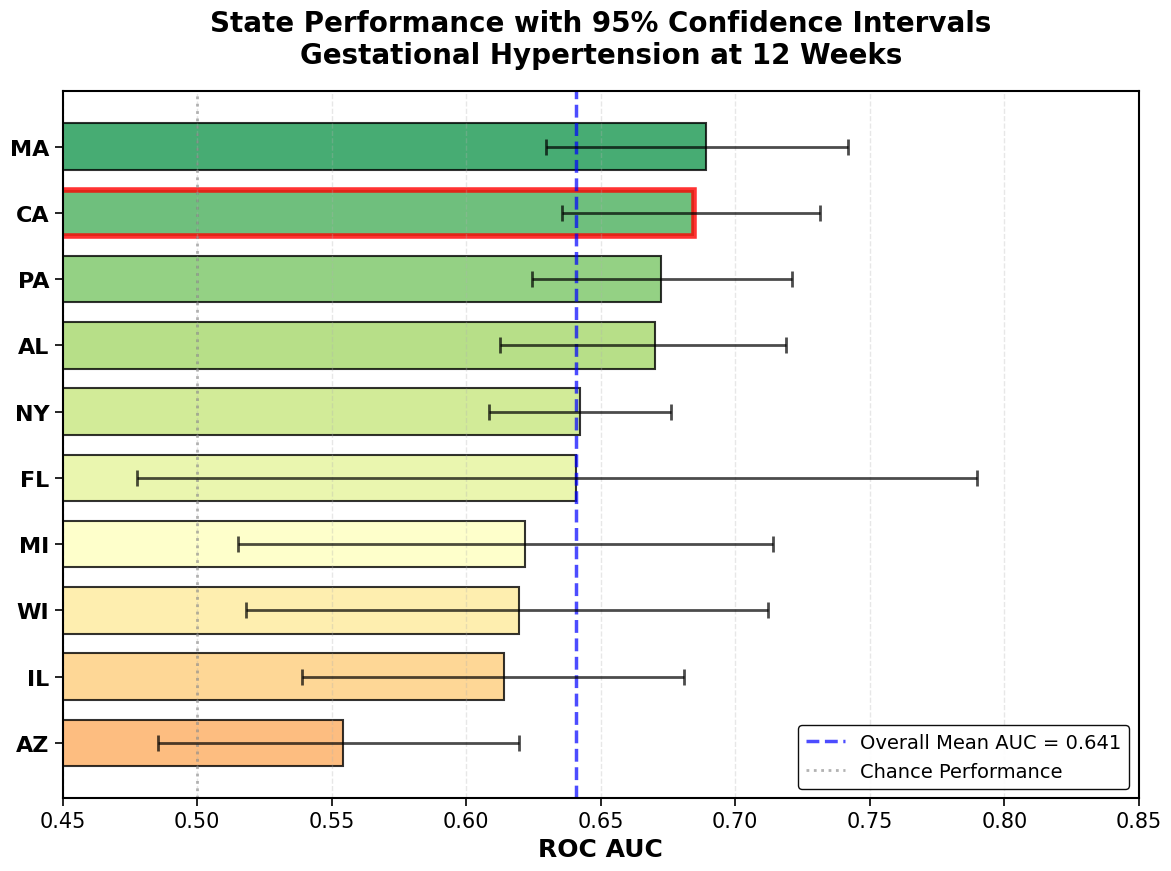

In [47]:
# # Standalone Code: State Performance Bar Chart with Confidence Intervals

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# print("\n" + "="*70)
# print("CREATING STATE PERFORMANCE BAR CHART WITH CONFIDENCE INTERVALS")
# print("="*70)

# state_results_sorted = state_results_df.sort_values('roc_auc', ascending=True)
# overall_auc_mean = state_results_df['roc_auc'].mean()

# error_lower = state_results_sorted['roc_auc'] - state_results_sorted['ci_lower']
# error_upper = state_results_sorted['ci_upper'] - state_results_sorted['roc_auc']

# fig, ax = plt.subplots(figsize=(12, 9))

# y_positions = range(len(state_results_sorted))
# colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(state_results_sorted)))

# bars = ax.barh(y_positions, 
#                state_results_sorted['roc_auc'],
#                color=colors,
#                edgecolor='black',
#                linewidth=1.5,
#                alpha=0.8,
#                height=0.7)

# ax.errorbar(state_results_sorted['roc_auc'],
#            y_positions,
#            xerr=[error_lower, error_upper],
#            fmt='none',
#            ecolor='black',
#            elinewidth=2,
#            capsize=6,
#            capthick=2,
#            alpha=0.7,
#            zorder=3)

# ca_idx = list(state_results_sorted['state']).index('CA') if 'CA' in list(state_results_sorted['state']) else None
# if ca_idx is not None:
#     bars[ca_idx].set_edgecolor('red')
#     bars[ca_idx].set_linewidth(4)

# ax.axvline(x=overall_auc_mean, color='blue', linestyle='--', 
#           alpha=0.7, linewidth=2.5, label=f'Overall Mean AUC = {overall_auc_mean:.3f}',
#           zorder=2)

# ax.axvline(x=0.5, color='gray', linestyle=':', 
#           alpha=0.6, linewidth=2, label='Chance Performance',
#           zorder=1)

# ax.set_yticks(y_positions)
# ax.set_yticklabels(state_results_sorted['state'], fontsize=16, fontweight='bold')
# ax.tick_params(axis='x', labelsize=15)

# ax.set_xlabel('ROC AUC', fontsize=18, fontweight='bold')
# ax.set_xlim([0.45, 0.85])

# ax.set_title('State Performance with 95% Confidence Intervals\nGestational Hypertension at 12 Weeks', 
#             fontsize=20, fontweight='bold', pad=20)

# ax.legend(fontsize=14, loc='lower right', framealpha=0.95, 
#          edgecolor='black', fancybox=True)

# ax.grid(True, alpha=0.3, axis='x', linestyle='--', linewidth=1)

# plt.tight_layout()

# figure_filename = 'state_performance_bars_with_CI.png'
# plt.savefig(figure_filename, dpi=300, bbox_inches='tight')
# print(f"\n✓ Figure saved as: {figure_filename}")
# plt.show()